**14th May 2026**

Input: Visual Cue, Limb Ocillations

Output: Position Prediction

In [114]:
import os
print(os.getcwd())


/Users/ais/Desktop/2026_Summer/correct data/25thjun


In [115]:
# prerequisites

#filename
file_name = "1d_pos_pred"
import datetime
today = datetime.date.today()

#basic_operations
import os
import math
import pickle

#math
from sympy import diff

#exploratory_data_analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from numpy.fft import fft, fftfreq

#data_generation 
from scipy.interpolate import splprep, splev

#deep_learning
import torch
import torch.nn as nn
from complexPyTorch.complexLayers import ComplexLinear, ComplexReLU
from torch.utils.data import TensorDataset, DataLoader, random_split

#gpu_usage
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist

#random_seed
torch.manual_seed(22)
np.random.seed(22)

# Constants
epsilon = 1e-10

In [116]:
# GPU Usage

# Check if CUDA is available
print("Is CUDA available?", torch.cuda.is_available())

# Total number of GPUs available
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")

# List all GPU names
for i in range(num_gpus):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda") if torch.cuda.is_available() is True else torch.device("cpu")
print(device)

Is CUDA available? False
Number of GPUs available: 0
cpu


In [117]:
# Trajectory Generation

# Units

# Distance - meters
# Angle - Radians
# Time - seconds

# Enviornment Paramaters
track_min, track_max = 0, 1
dt = 0.01
total_time = 10
total_time_series = np.arange(0, total_time, dt)
total_time_steps = int(total_time/ dt)

def generate_trajectory(velocity_magnitude):
    
    # random initial position
    initial_position = np.random.uniform(0, 1)
    
    time_left = total_time
    segment_count = 0
    traj_data, trajectory_data = [], []
    current_step = initial_position

    while time_left > 0:

        # Segmentation of time
        segment_duration = np.random.choice(range(1, time_left+1))
        time_left = time_left - segment_duration
        segment_count += 1

        # Choosing initial direction
        eps = 1e-6
        if current_step <= track_min + eps:
            current_direction = 1
        elif current_step >= track_max - eps:
            current_direction = -1
        else:
            current_direction = np.random.choice([-1, 0, 1], p=[0.5, 0.1, 0.4])

        # Updating position every time step based on direction
        segment_data = []
        for i in range(int(segment_duration/dt)):
            
            next_step = current_step + current_direction * velocity_magnitude * dt
            # Check if next step is within bounds
            if next_step < track_min or next_step > track_max:
                wall_action = np.random.choice(["bounce", "rest"], p=[0.8, 0.2])    
                if wall_action == "bounce":
                    current_direction = current_direction * -1
                    next_step = current_step + current_direction * velocity_magnitude * dt    
                else:  # rest at wall
                    current_direction = 0
                    next_step = current_step
                #next_step = np.clip(next_step, track_min, track_max)

            velocity_vector = current_direction * velocity_magnitude
            segment_data.append((current_step, velocity_vector))
            current_step = next_step

        traj_data.extend(segment_data)
        
    #print("Segment_Count", segment_count)
    trajectory_data.extend(traj_data)
    trajectory_data = np.array(trajectory_data)
    return trajectory_data

In [118]:
# Visual Cue Generation (1D version)

def generate_visual_cue_1d(position_series, track_min=0, track_max=1):
    """
    Generate visual cues as inverse distances to track boundaries.
    
    """
    position_series = np.array(position_series)
    T = len(position_series)
    
    visual_cues = np.zeros((T, 2), dtype=np.float32)
    
    # Distance to left boundary (track_min)
    dist_to_min = np.abs(position_series - track_min)
    visual_cues[:, 0] = 1.0 - dist_to_min
    
    # Distance to right boundary (track_max)
    dist_to_max = np.abs(position_series - track_max)
    visual_cues[:, 1] = 1.0 - dist_to_max
    
    return visual_cues

In [119]:
# Limb Oscillation Generation
# Amplitude is uniform, frequency of the oscillations is proportional to velocity of agent (magnitude and direction)

# Agent Parameters
am = 0.1        # stride length (m)
phi = math.pi  # contralateral phase offset
theta_m = 1.0        # CONSTANT amplitude (uniform limb motion)

def generate_trajectory_limb_data(num_trajectories):

    trajectory, trajectory_data = [], []
    UFL_data, UFR_data, UHL_data, UHR_data = [], [], [], []
    visual_cue_data = []
    phase_data = []
    omega_data = []

    for trajectory in range(num_trajectories):

        # Generate trajectory
        velocity_magnitude = np.random.uniform(0.1, 1.0)
        trajectory = generate_trajectory(velocity_magnitude)

        # Extract trajectory signals
        position_series = trajectory[:, 0]   # position
        velocity_series = trajectory[:, 1]   # signed velocity
        # Visual cues (pure position)
        visual_cues = generate_visual_cue_1d(position_series, track_min, track_max)

        # Signed angular frequency ω(t)
        omega_t = 2 * np.pi * (velocity_series / am)

        # Phase integration
        #phase_t = omega_t * total_time_series
        phase_t = np.cumsum(omega_t * dt)

        # Uniform-amplitude limb oscillations
        UFL = theta_m * np.sin(phase_t )
        UFR = theta_m * np.sin(phase_t + phi)
        UHL = theta_m * np.sin(phase_t + phi)
        UHR = theta_m * np.sin(phase_t)

        trajectory_data.append(trajectory)
        UFL_data.append(UFL)
        UFR_data.append(UFR)
        UHL_data.append(UHL)
        UHR_data.append(UHR)
        visual_cue_data.append(visual_cues)
        phase_data.append(phase_t)
        omega_data.append(omega_t)

    trajectory_data = np.array(trajectory_data)
    limb_oscillations = np.stack(
        [UFL_data, UFR_data, UHL_data, UHR_data], axis=-1
    )
    visual_cue_data = np.array(visual_cue_data)
    phase_data = np.array(phase_data)
    omega_data = np.array(omega_data)

    return visual_cue_data, trajectory_data, limb_oscillations, phase_data, omega_data

In [120]:
def structure_data_to_dicts(visual_cue_data, trajectory_data, limb_oscillations, phase_data, omega_data):
    """
    Structure trajectory, limb, and visual cue data into X (inputs) and Y (outputs) dictionaries.

    Parameters:
    -----------
    visual_cue_data : array, shape (N, T_timesteps, 2) - 1/d to 0 and 1
    trajectory_data : array, shape (N, T_timesteps, 2) - position and velocity
    limb_oscillations : array, shape (N, T_timesteps, 4) - all limb oscillations
    phase_data : array, shape (N, T_timesteps) - phase of limb oscillations
    omega_data : array, shape (N, T_timesteps) - angular frequency of limb oscillations

    Returns:
    --------
    inputs : dict with keys ['visual_cue', 'limb_osc', 'phase', 'omega']
    outputs : dict with keys ['position', 'velocity']
    """

    # Extract inputs (inputs) - NO initial_pos, NO direction
    inputs = {
        'visual_cue': visual_cue_data,             # (N, T, 2) - 1/distance to track_min and track_max
        'limb_osc': limb_oscillations,             # (N, T, 4) - all limb oscillations
        'phase': phase_data,                       # (N, T) - phase from omega integration
        'omega': omega_data                        # (N, T) - angular frequency
    }

    # Extract outputs (outputs)
    outputs = {
        'position': trajectory_data[:, :, 0],  # (N, T) - current position
        'velocity': trajectory_data[:, :, 1]   # (N, T) - signed velocity
    }

    return inputs, outputs

In [121]:
visual_cue_data, trajectory_data, limb_oscillations, phase_data, omega_data = generate_trajectory_limb_data(num_trajectories=500)

inputs, outputs = structure_data_to_dicts(visual_cue_data, trajectory_data, limb_oscillations, phase_data, omega_data)

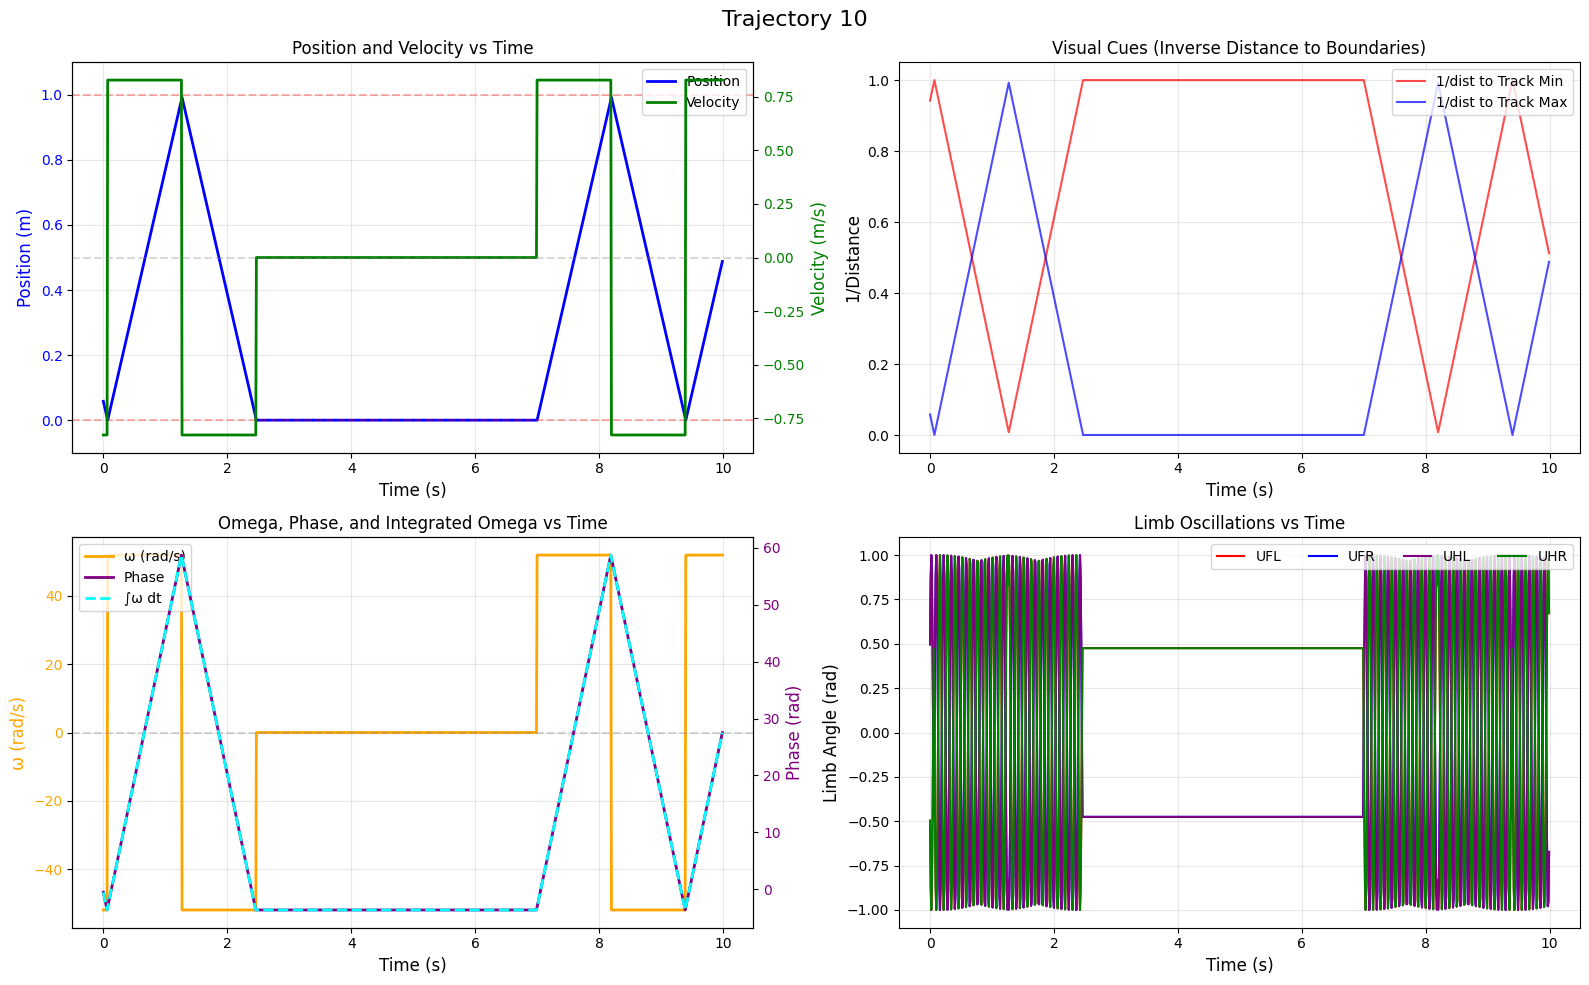

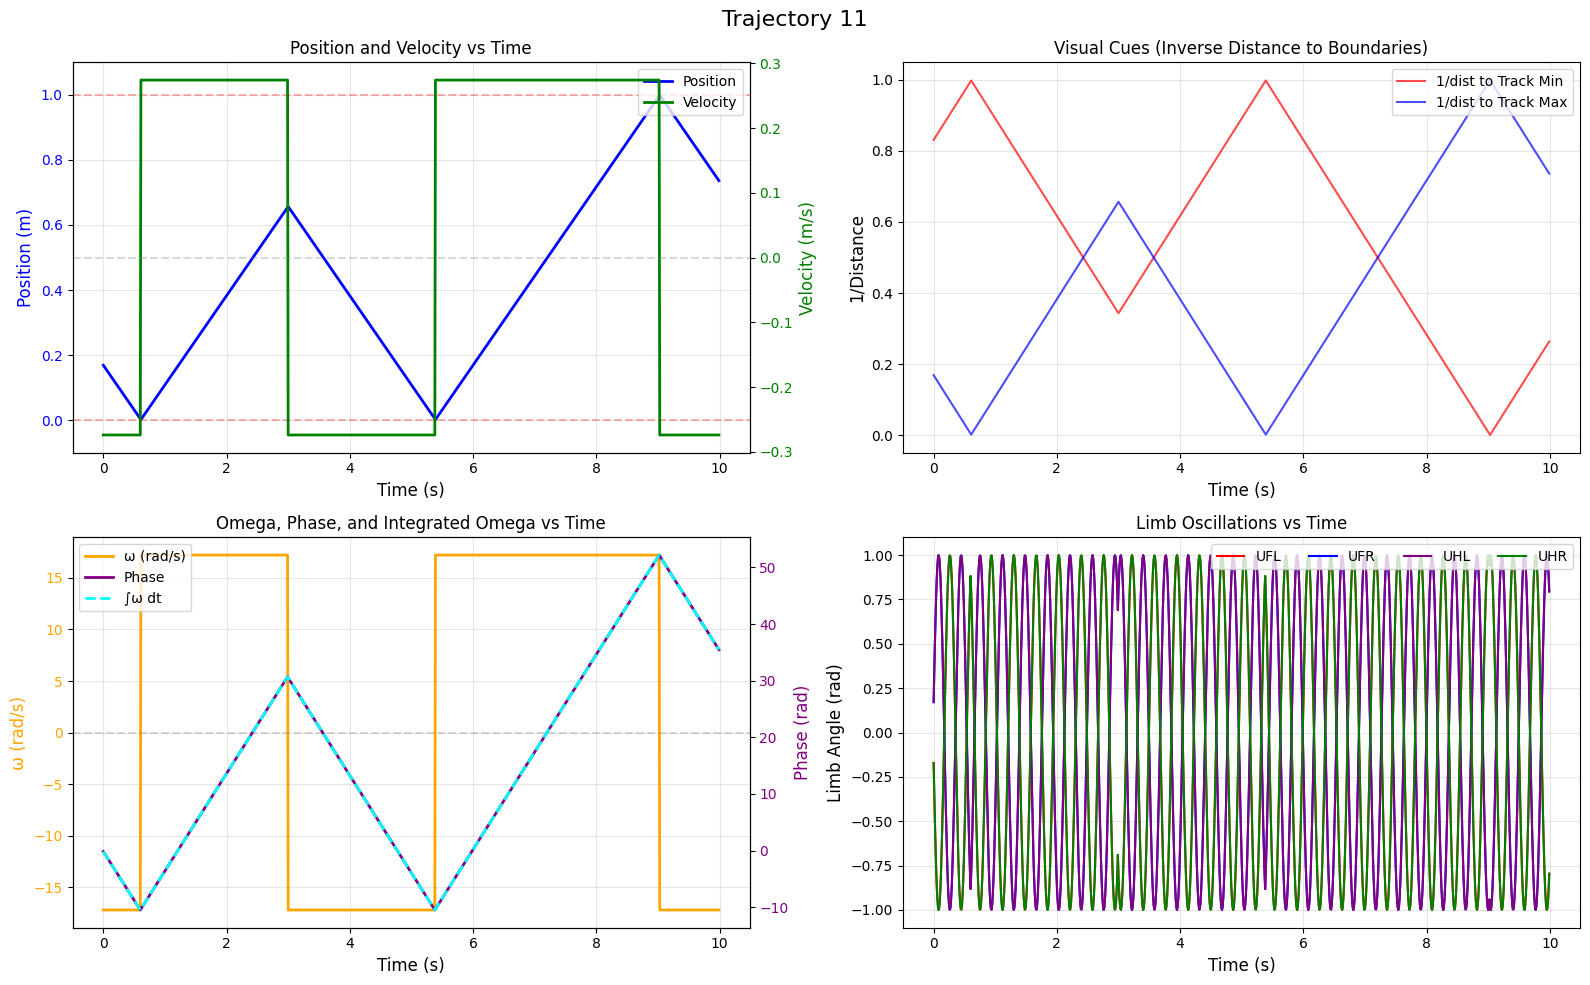

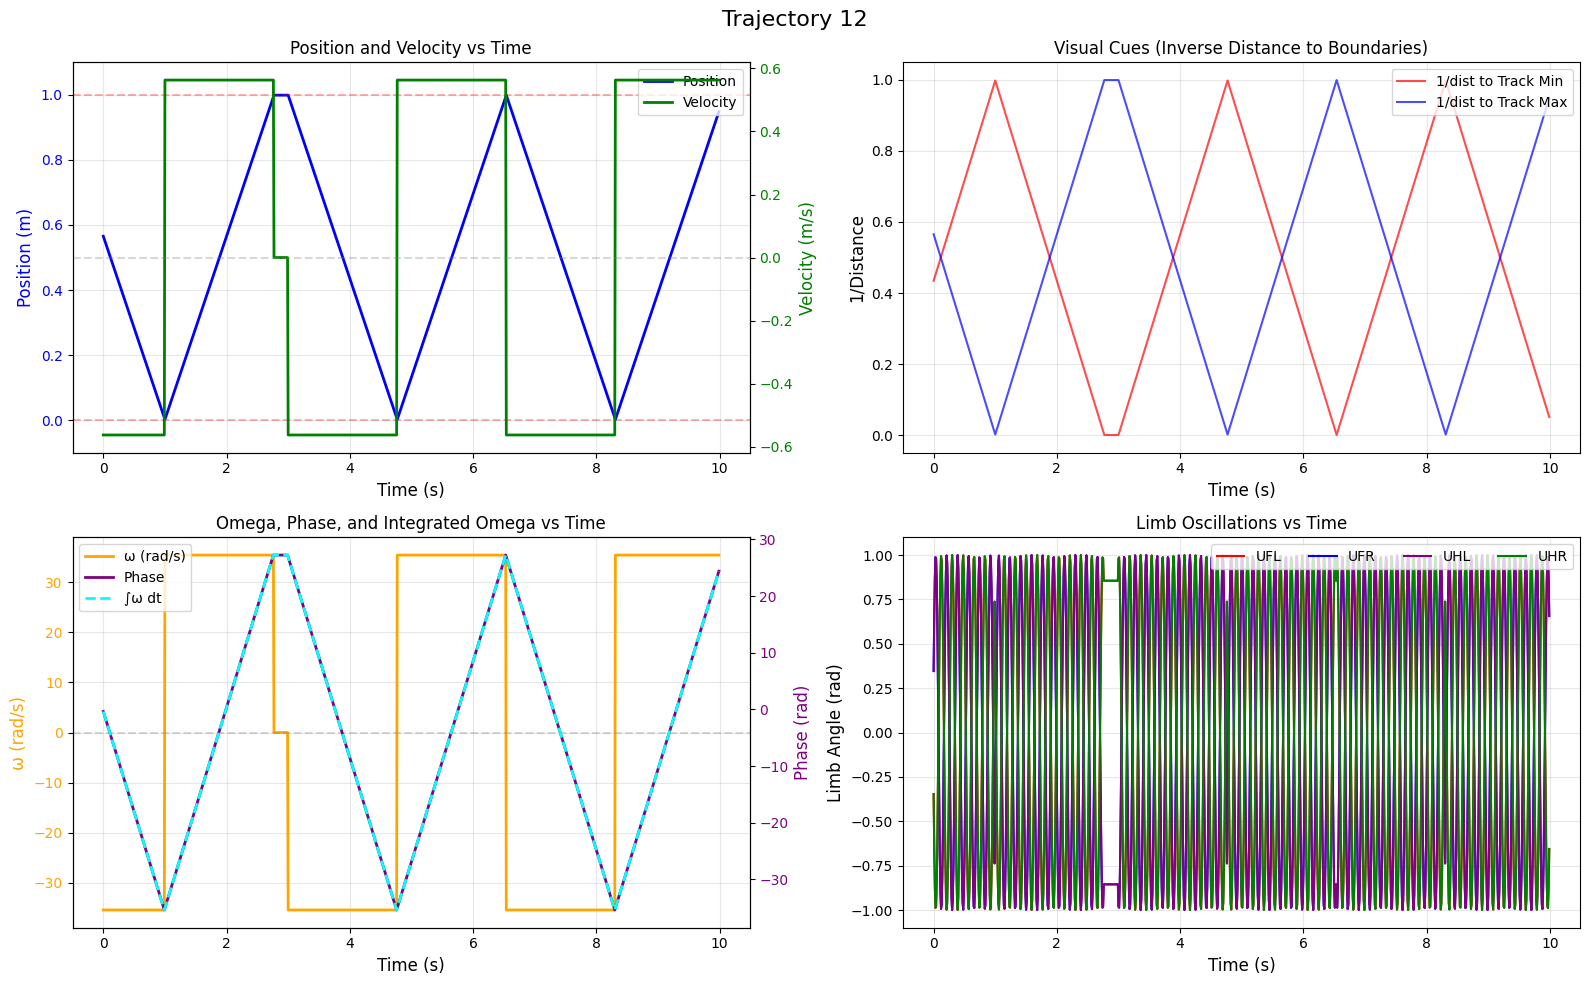

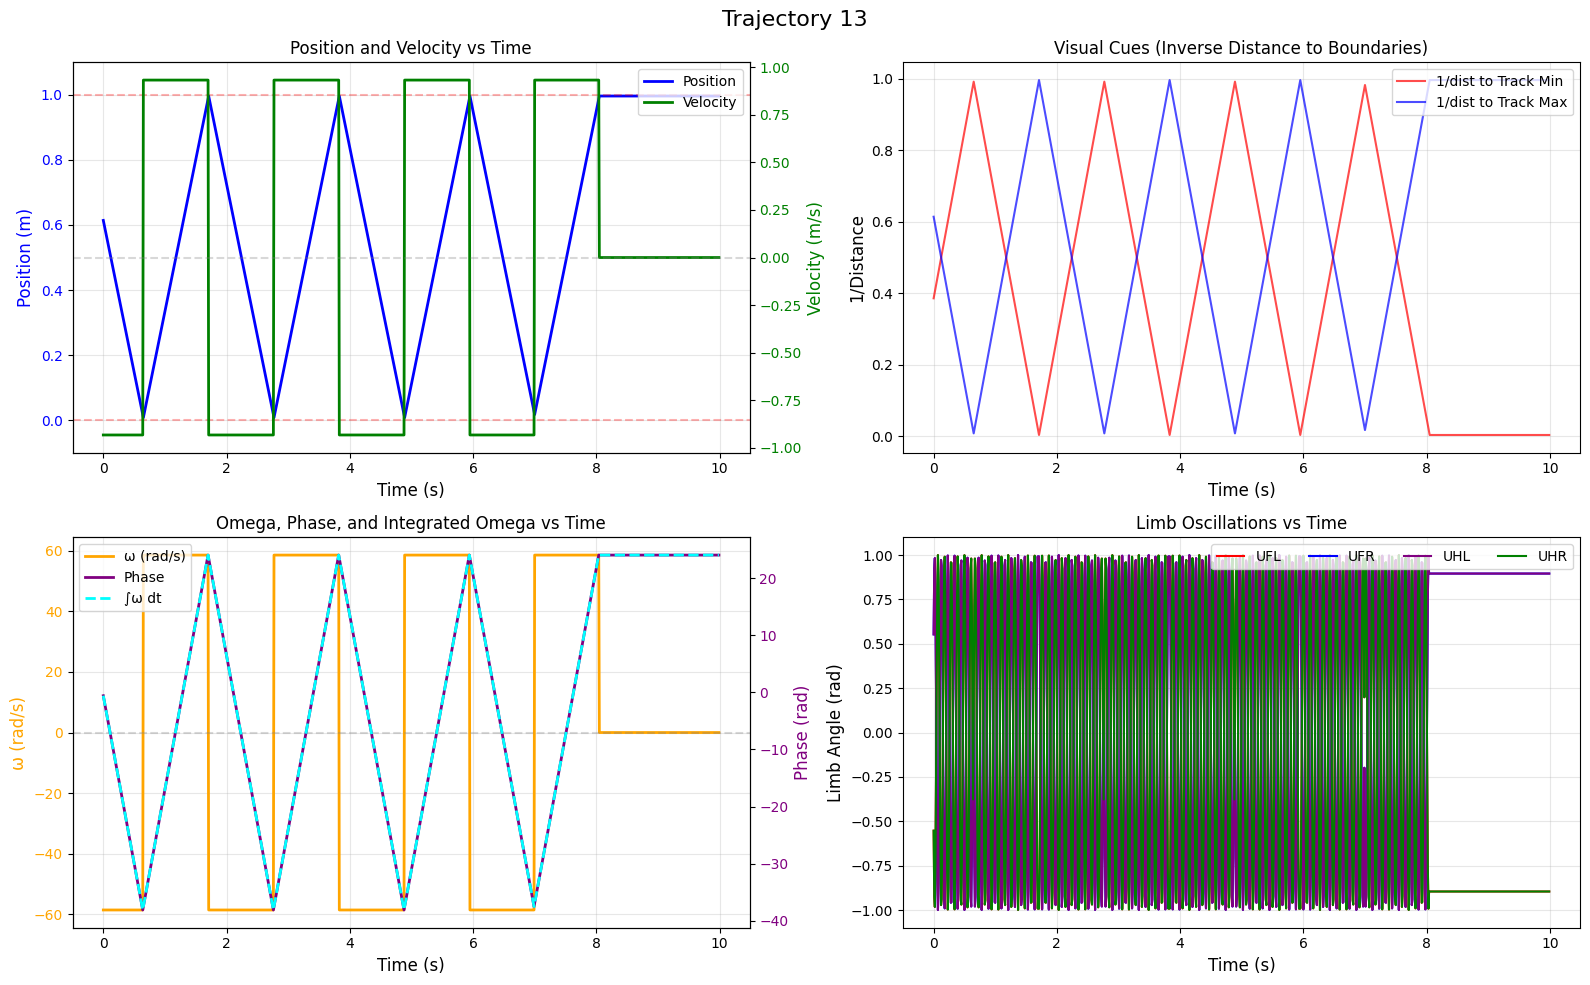

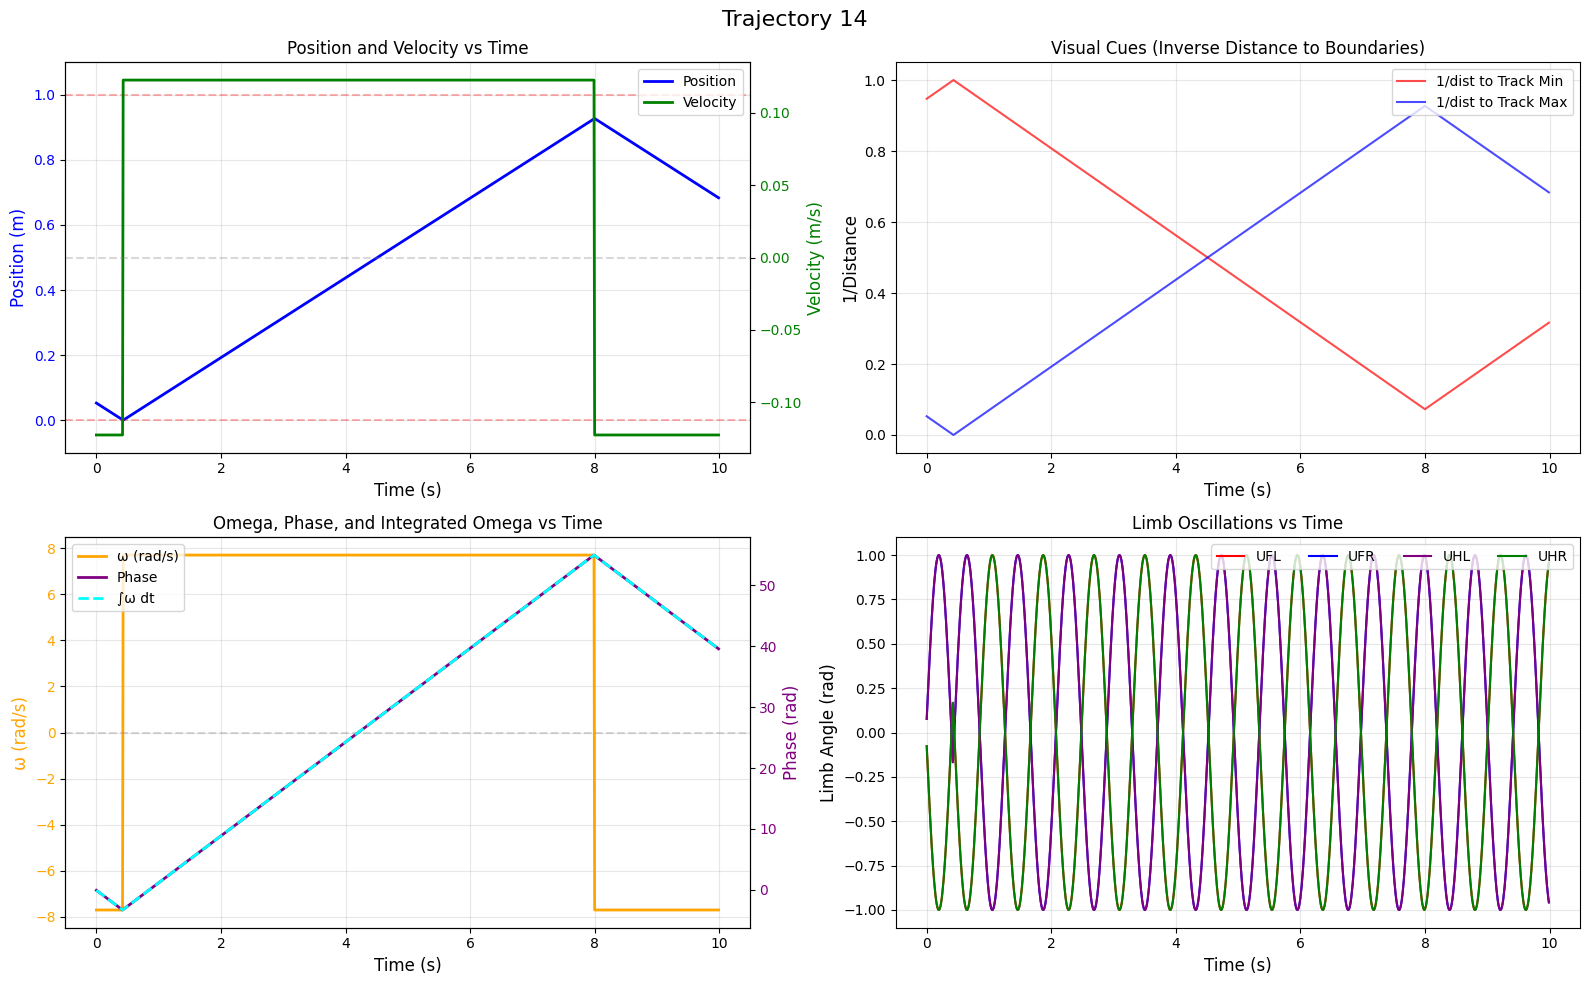

In [122]:
def plot_1d_data(inputs, outputs, time_series, num_plots=5):
    """
    Plot 1D trajectory data in 2-column layout:
    Left column: Position/Velocity, Phase/Omega
    Right column: Visual Cues, Limb Oscillations
    """
    for i in range(num_plots):
        traj_index = i + 10
        
        # Extract data for current trajectory
        position = outputs['position'][traj_index]
        velocity = outputs['velocity'][traj_index]
        limb_osc = inputs['limb_osc'][traj_index]
        visual_cue = inputs['visual_cue'][traj_index]
        phase = inputs['phase'][traj_index]
        omega = inputs['omega'][traj_index]
        UFL, UFR, UHL, UHR = limb_osc.T
        
        # Compute integrated omega for comparison
        integrated_omega = np.cumsum(omega * dt)
        
        # Create figure with 2x2 grid
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"Trajectory {traj_index}", fontsize=16)
        
        # ============ LEFT COLUMN ============
        
        # Plot 1 (top-left): Position and Velocity
        ax1 = axes[0, 0]
        ax1_vel = ax1.twinx()
        
        line1, = ax1.plot(time_series, position, color='blue', linewidth=2, label='Position')
        ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3)
        ax1.axhline(y=1, color='red', linestyle='--', alpha=0.3)
        ax1.set_ylabel('Position (m)', fontsize=12, color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(-0.1, 1.1)
        
        line2, = ax1_vel.plot(time_series, velocity, color='green', linewidth=2, label='Velocity')
        ax1_vel.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        ax1_vel.set_ylabel('Velocity (m/s)', fontsize=12, color='green')
        ax1_vel.tick_params(axis='y', labelcolor='green')
        
        ax1.set_xlabel('Time (s)', fontsize=12)
        ax1.set_title('Position and Velocity vs Time')
        ax1.legend([line1, line2], ['Position', 'Velocity'], loc='upper right')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2 (bottom-left): Omega, Phase, and Integrated Omega
        ax2 = axes[1, 0]
        ax2_phase = ax2.twinx()
        
        line3, = ax2.plot(time_series, omega, color='orange', linewidth=2, label='ω (rad/s)')
        ax2.set_ylabel('ω (rad/s)', fontsize=12, color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')
        ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        
        line4, = ax2_phase.plot(time_series, phase, color='purple', linewidth=2, label='Phase')
        line5, = ax2_phase.plot(time_series, integrated_omega, color='cyan', linewidth=2, 
                                 linestyle='--', label='∫ω dt')
        ax2_phase.set_ylabel('Phase (rad)', fontsize=12, color='purple')
        ax2_phase.tick_params(axis='y', labelcolor='purple')
        
        ax2.set_xlabel('Time (s)', fontsize=12)
        ax2.set_title('Omega, Phase, and Integrated Omega vs Time')
        ax2.legend([line3, line4, line5], ['ω (rad/s)', 'Phase', '∫ω dt'], loc='upper left')
        ax2.grid(True, alpha=0.3)
        
        # ============ RIGHT COLUMN ============
        
        # Plot 3 (top-right): Visual Cues
        ax3 = axes[0, 1]
        ax3.plot(time_series, visual_cue[:, 0], label='1/dist to Track Min', 
                color='red', linewidth=1.5, alpha=0.7)
        ax3.plot(time_series, visual_cue[:, 1], label='1/dist to Track Max', 
                color='blue', linewidth=1.5, alpha=0.7)
        ax3.set_xlabel('Time (s)', fontsize=12)
        ax3.set_ylabel('1/Distance', fontsize=12)
        ax3.set_title('Visual Cues (Inverse Distance to Boundaries)')
        ax3.legend(loc='upper right')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4 (bottom-right): Limb Oscillations
        ax4 = axes[1, 1]
        ax4.plot(time_series, UFL, label='UFL', color='red', linewidth=1.5)
        ax4.plot(time_series, UFR, label='UFR', color='blue', linewidth=1.5)
        ax4.plot(time_series, UHL, label='UHL', color='purple', linewidth=1.5)
        ax4.plot(time_series, UHR, label='UHR', color='green', linewidth=1.5)
        ax4.set_xlabel('Time (s)', fontsize=12)
        ax4.set_ylabel('Limb Angle (rad)', fontsize=12)
        ax4.set_title('Limb Oscillations vs Time')
        ax4.legend(ncol=4, loc='upper right')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

plot_1d_data(inputs, outputs, total_time_series, num_plots=5)

In [123]:
# Count motion types from velocity data
velocities = outputs['velocity'].flatten()

forward = np.sum(velocities > 0)
backward = np.sum(velocities < 0)
rest = np.sum(velocities == 0)
total = len(velocities)

print(f"Forward:  {forward/total*100:.1f}%")
print(f"Backward: {backward/total*100:.1f}%")
print(f"Rest:     {rest/total*100:.1f}%")


Forward:  32.7%
Backward: 33.4%
Rest:     33.9%


In [124]:
# Concatenate inputs: visual_cue (2) + limb_osc (4) = 6 features total
# No initial_pos, no direction
X = np.concatenate([inputs['visual_cue'], inputs['limb_osc']], axis=-1)  # (N, T, 6)
Y = outputs['position'][:,:,np.newaxis]  # (N, T, 1)

In [125]:
print(X.shape, Y.shape)

(500, 1000, 6) (500, 1000, 1)


In [126]:
inputs.keys(), outputs.keys()

(dict_keys(['visual_cue', 'limb_osc', 'phase', 'omega']),
 dict_keys(['position', 'velocity']))

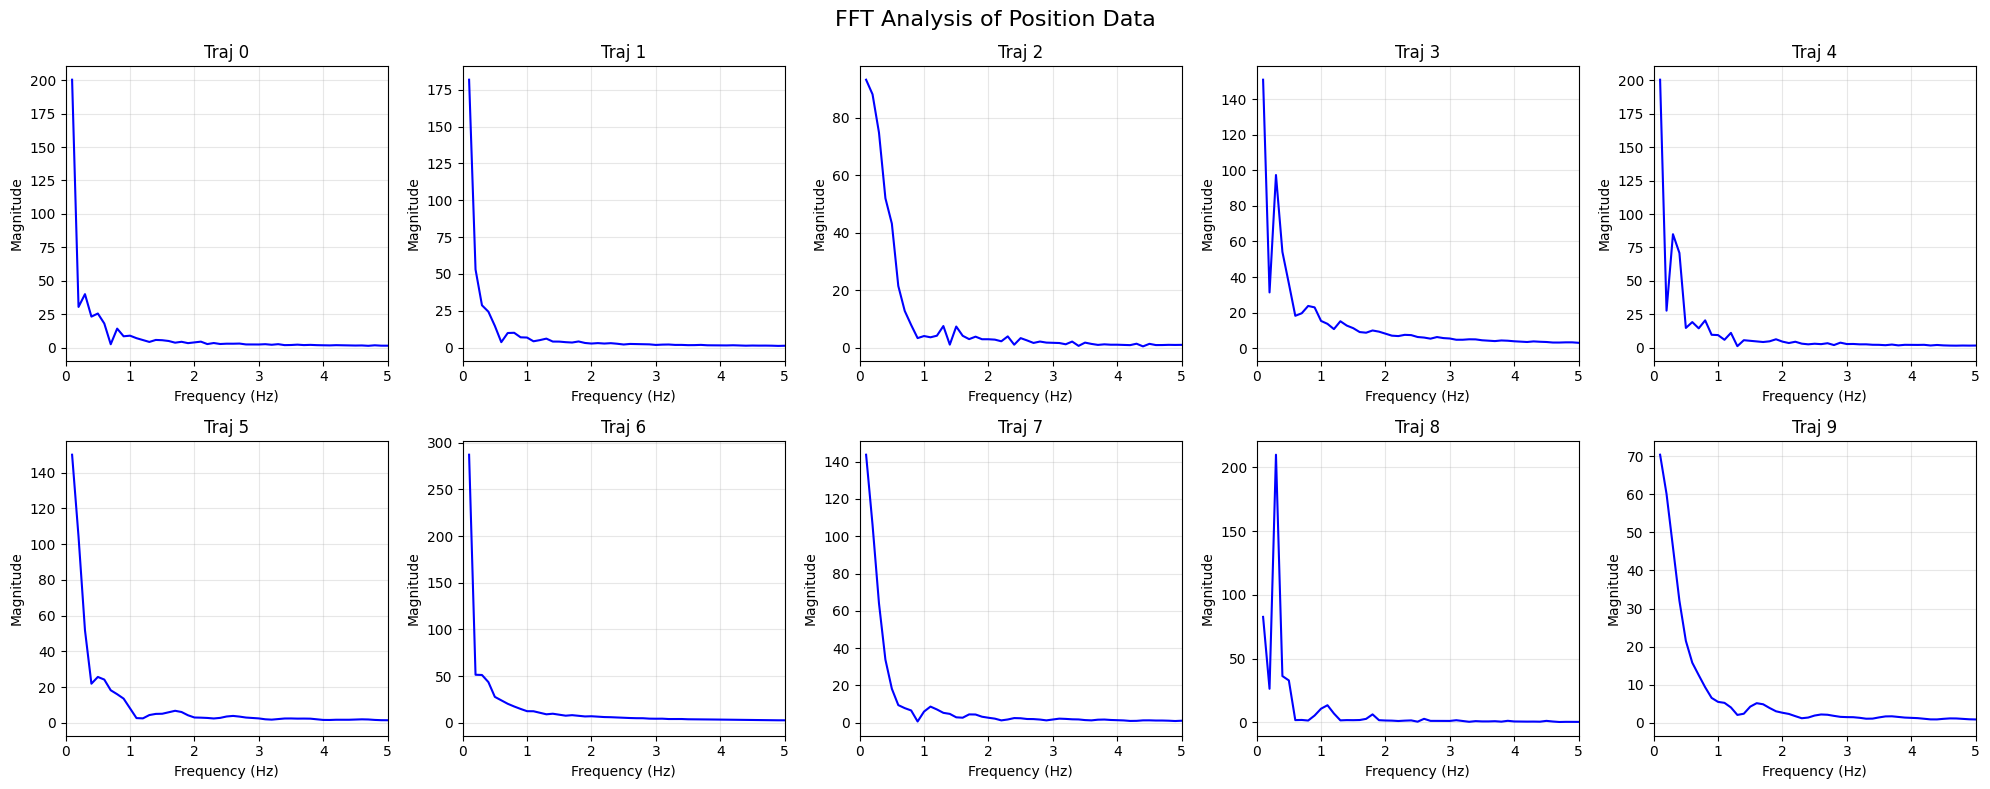

In [127]:
# FFT Analysis

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('FFT Analysis of Position Data', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    traj_index = i
    position = outputs['position'][traj_index, :]
    
    # Compute FFT
    fft_pos = fft(position)
    n = len(position)
    frequencies = fftfreq(n, d=dt)
    magnitude = np.abs(fft_pos)
    
    # Plot magnitude spectrum
    ax.plot(frequencies[1:n // 2], magnitude[1:n // 2], color='blue', linewidth=1.5)
    ax.set_title(f'Traj {traj_index}')
    ax.set_xlim(0, 5)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Network Training - Position & Velocity Prediction

In [131]:
#Hopf Oscillator

def real_cal(r, phi):
    return r * torch.cos(phi)

def imag_cal(r, phi):
    return r * torch.sin(phi)


def oscillator_loop(X_r, X_i, omegas, num_steps, dt=0.01, input_scaler=5):
    
    """
    X_r, X_i: real and imaginary parts of input signal [batch, time, units]
    omegas: angular frequencies of oscillators [1, units]
    num_steps: number of time steps
    """

    batch_size, _, units = X_r.shape
    

    # amplitude and phase initialisation
    r_t = torch.ones((batch_size, units), device=X_r.device)
    phis = torch.zeros((batch_size, units), device=X_r.device)

    #r_t = 0.9 + 0.2 * torch.rand((batch_size, units), device=X_r.device)
    #phis = (2 * math.pi) * torch.rand((batch_size, units), device=X_r.device) - math.pi

    r_list, phi_list = [], []

    for t in range(num_steps):
        # input at current time step
        input_r = input_scaler * X_r[:, t, :] * torch.cos(phis)
        input_phi = input_scaler * X_i[:, t, :] * torch.sin(phis)

        # Hopf oscillator update equations
        r_t = r_t + ((1 - r_t**2) * r_t + input_r) * dt
        phis = phis + (omegas - input_phi) * dt

        r_list.append(r_t.unsqueeze(1))   # keep time dimension
        phi_list.append(phis.unsqueeze(1))

    # Stack time axis -> shape [batch, time, units]
    r_arr = torch.cat(r_list, dim=1)
    phi_arr = torch.cat(phi_list, dim=1)
    return r_arr, phi_arr



class Hopf(nn.Module):
    def __init__(self, units, num_steps, min_f=0.1, max_f=10.1):
        super(Hopf, self).__init__()
        self.units = units
        self.num_steps = num_steps

        # Frequencies equally spaced between min_f and max_f
        omegas = torch.linspace(min_f, max_f, units) * (2 * math.pi)
        self.register_buffer('omegas', omegas.unsqueeze(0))  # [1, units]

    def forward(self, z_complex):
        """
        z_complex: complex input tensor [batch, time, units]
        """
        X_r = z_complex.real
        X_i = z_complex.imag

        # r, phi = oscillator_loop(X_r, X_i, self.omegas, self.num_steps)
        r, phi = oscillator_loop(X_r, X_i, self.omegas, X_r.shape[1])


        z_real = real_cal(r, phi)
        z_imag = imag_cal(r, phi)
        return torch.complex(z_real, z_imag)


In [132]:
# Time Distributed layer in pytorch
   

class TimeDistributed(nn.Module):
    """
    Applies a module (e.g. Linear, Conv, etc.) to each time step independently.
    Input shape:  [batch, time, features]
    Output shape: [batch, time, output_features]
    """
    def __init__(self, module):
        super(TimeDistributed, self).__init__()
        self.module = module

    def forward(self, x):
        # If input is already 2D (no time dimension)
        if len(x.size()) <= 2:
            return self.module(x)

        batch_size, time_steps, features = x.size()
        x_reshaped = x.contiguous().view(batch_size * time_steps, features)
        y = self.module(x_reshaped)
        # Restore shape
        y = y.contiguous().view(batch_size, time_steps, -1)
        return y



In [133]:
class DONN(nn.Module):
    def __init__(self, units, duration):
        super(DONN, self).__init__()

        # -----------------------------
        # Complex Dense + Hopf layers
        # -----------------------------
        self.d1 = nn.Sequential(
            TimeDistributed(ComplexLinear(X.shape[-1], units)),
            ComplexReLU(),
            
        )
        self.osc1 = Hopf(units, num_steps=duration, min_f=1, max_f=10)

        self.d2 = nn.Sequential(
            TimeDistributed(ComplexLinear(units, units)),
            ComplexReLU(),
            
        )
        self.osc2 = Hopf(units, num_steps=duration, min_f=4, max_f=8)

        self.d3 = nn.Sequential(
            TimeDistributed(ComplexLinear(units, units)),
            ComplexReLU(),
            
        )
        self.osc3 = Hopf(units, num_steps=duration, min_f=0.1, max_f=3)

        self.d4 = nn.Sequential(
            TimeDistributed(nn.Linear(units, units)),
            nn.ReLU(),
            
        )

        # -----------------------------
        # Real-valued output heads
        # -----------------------------
        self.pos_out = nn.Sequential(
            nn.Linear(units, 1),  # for (x, y)
            nn.Sigmoid()
        )

        # self.hd_out = nn.Sequential(
        #     nn.Linear(units * 2, 2),  
        #     nn.Tanh()
            
        # )

        # For storing intermediate outputs
        self.d1_out = None
        self.osc1_out = None
        self.d2_out = None
        self.osc2_out = None
        self.d3_out = None
        self.osc3_out = None

        

    def forward(self, X):
        """
        X: [batch, time, units] real input signal
        """

        # Input Convert to complex
        X_c = torch.complex(X, torch.zeros_like(X))

        # 3 pairs of sequential complex transformations + Hopf oscillations
        d1 = self.d1(X_c)
        z1 = self.osc1(d1)
        self.z1 = z1

        d2 = self.d2(z1)
        z2 = self.osc2(d2)
        self.z2 = z2

        d3 = self.d3(z2)
        z3 = self.osc3(d3)
        self.z3 = z3

        z3_abs = torch.abs(z3)
        #z3_concat = torch.cat([z3.real, z3.imag], dim=-1)

        d4 = self.d4(z3_abs)
        
        
        pos_out = self.pos_out(d4)
        

        #Scaling or Nomalisations
        #hd_scaled = hd_out * math.pi  # Scale to [-pi, pi]
        #hd_norm = hd_out / (torch.norm(hd_out, dim=-1, keepdim=True) + 1e-8)
        
    
        return {"position": pos_out}
        #return {"pos": pos_out, "hd": hd_out}

In [134]:
# ========================GPU Usage========================
# Template:
'''
Instantiate the model
Define primary device
Move model to primary device
Wrap things like DataParallel or DDP if needed
'''

# To use any GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#To use a specific GPU
#device = torch.device("cuda:0")
#model.to(device)

# To use all GPUs in parallel
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# model = model.to(device)
# if torch.cuda.device_count() > 1:
#     print("Using", torch.cuda.device_count(), "GPUs")
#     model = nn.DataParallel(model)

# To use a specific SET of GPUs
# device_ids = [1, 2, 3]
# device = torch.device(f'cuda:{device_ids[0]}')
# model = model.to(f'cuda:{device_ids[0]}')
# model = nn.DataParallel(model, device_ids=device_ids)

# Distributed Data Parallel (DDP)
# For large processes
# Code modularization needed for this


# ========================GPU Usage========================


In [135]:
# Hyperparameters
units = 50
learning_rate = 0.01
batch_size = 100
#epochs = 300

duration = total_time_steps  # same as in TF version

model = DONN(units=units, duration=duration).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    # verbose=True
)
mse_loss = nn.MSELoss()

#Print the GPUs being used
print("Model is running on:", next(model.parameters()).device)


Model is running on: cpu


In [136]:
# Convert NumPy arrays to PyTorch tensors
X_tensor = torch.tensor(X[:500, :, :], dtype=torch.float32)
Y_pos_tensor = torch.tensor(Y[:500, :, :], dtype=torch.float32)

# Combine into one dataset
dataset = TensorDataset(X_tensor, Y_pos_tensor)

# 60-40 train-validation split
val_size = int(0.3 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

print("Train data shape:", X_tensor.shape, Y_pos_tensor.shape)

Train data shape: torch.Size([500, 1000, 6]) torch.Size([500, 1000, 1])


In [137]:
def training_loop(model, optimizer, scheduler, train_loader, val_loader, start_epoch, end_epoch, early_stop_patience=30, use_scheduler=False, use_early_stopping=False):

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    
    prev_lr = optimizer.param_groups[0]['lr']

    for epoch in range(start_epoch, end_epoch):
        model.train()
        total_loss = 0.0
        
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{end_epoch}", leave=False)
        
        for X_batch, Y_pos_batch in batch_bar:
            X_batch, Y_pos_batch = X_batch.to(device), Y_pos_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)

            pos_out = predictions["position"]
            

            # Compute combined loss
            loss_pos = mse_loss(pos_out, Y_pos_batch)
            loss = loss_pos
            

            loss.backward()
            #nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for X_val, Y_pos_val in val_loader:
                X_val, Y_pos_val = X_val.to(device), Y_pos_val.to(device)
                val_predictions = model(X_val)
                pos_pred = val_predictions["position"]
                val_loss += (mse_loss(pos_pred, Y_pos_val)).item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if use_scheduler and scheduler is not None:
            scheduler.step(avg_val_loss)
            # explicit logging using new API
            last_lr = scheduler.get_last_lr()  # returns list per param_group
            if (epoch + 1) % 10 == 0 or epoch == 0:
                tqdm.write(f"LR after scheduler step: {last_lr}")
                
            
        # Early Stopping Check

        current_lr = optimizer.param_groups[0]['lr']

        if use_early_stopping:
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
            elif current_lr < prev_lr:
                patience_counter = 0
            else:
                patience_counter += 1
            prev_lr = current_lr

            if patience_counter >= early_stop_patience:
                tqdm.write("Early stopping triggered")
                break

        #if (epoch + 1) % 10 == 0 or epoch == 0:
            
        tqdm.write(f"Epoch [{epoch+1}/{end_epoch}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")


    return model, optimizer, scheduler, epoch+1, train_losses, val_losses

In [138]:
resume_training = False
total_epochs = 1000

In [139]:
# If resuming training

if resume_training:
    checkpoint_path = f"1_network_data/weights/{file_name}_epoch_300.pth"

    # Load saved model and optimizer
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"]
    print(f"Resumed from epoch {start_epoch}")

else:
    start_epoch = 0

end_epoch = start_epoch + total_epochs

In [140]:
"""model, optimizer, scheduler, last_epoch, train_losses, val_losses = training_loop(
    model, optimizer, scheduler, train_loader, val_loader,
    start_epoch, end_epoch)"""

'model, optimizer, scheduler, last_epoch, train_losses, val_losses = training_loop(\n    model, optimizer, scheduler, train_loader, val_loader,\n    start_epoch, end_epoch)'

In [141]:
"""# Plot training history

plt.figure(figsize=(10, 6))
plt.plot(range(start_epoch+1, last_epoch+1), train_losses, label='Train Loss')
plt.plot(range(start_epoch+1, last_epoch+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()"""

"# Plot training history\n\nplt.figure(figsize=(10, 6))\nplt.plot(range(start_epoch+1, last_epoch+1), train_losses, label='Train Loss')\nplt.plot(range(start_epoch+1, last_epoch+1), val_losses, label='Validation Loss')\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\nplt.title('Training and Validation Loss over Epochs')\nplt.yscale('log')\nplt.legend()\nplt.grid(True, alpha=0.3)\nplt.show()"

In [142]:
"""# Saving weights 

weights_path = "1_network_data/weights"
weights_file = f"{today}{file_name}{end_epoch}.pth"

torch.save({
    'epoch': end_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses
}, f"{weights_path}/{weights_file}")

print("Weights saved successfully at:", f"{weights_path}/{weights_file}")"""

'# Saving weights \n\nweights_path = "1_network_data/weights"\nweights_file = f"{today}{file_name}{end_epoch}.pth"\n\ntorch.save({\n    \'epoch\': end_epoch,\n    \'model_state_dict\': model.state_dict(),\n    \'optimizer_state_dict\': optimizer.state_dict(),\n    \'train_losses\': train_losses,\n    \'val_losses\': val_losses\n}, f"{weights_path}/{weights_file}")\n\nprint("Weights saved successfully at:", f"{weights_path}/{weights_file}")'

In [143]:
#print("Weights saved successfully at:", f"{weights_path}/{weights_file}")

In [144]:
# Loading model for prediction (no training)

#device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
end_epoch = total_epochs
# Initialize model exactly the same way
model = DONN(units=units, duration=total_time_steps).to(device)

weights_path = "../../0_data_files/weights"
weights_file = f"1d_weights_v2_1000e.pth"

checkpoint = torch.load(f"{weights_file}", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.load_optimizer_state_dict = checkpoint["optimizer_state_dict"]
#model.eval()
print("Model loaded for inference (no training).")


Model loaded for inference (no training).


In [145]:
print("State Dictionary:", checkpoint["model_state_dict"].keys())

State Dictionary: odict_keys(['d1.0.module.fc_r.weight', 'd1.0.module.fc_r.bias', 'd1.0.module.fc_i.weight', 'd1.0.module.fc_i.bias', 'osc1.omegas', 'd2.0.module.fc_r.weight', 'd2.0.module.fc_r.bias', 'd2.0.module.fc_i.weight', 'd2.0.module.fc_i.bias', 'osc2.omegas', 'd3.0.module.fc_r.weight', 'd3.0.module.fc_r.bias', 'd3.0.module.fc_i.weight', 'd3.0.module.fc_i.bias', 'osc3.omegas', 'd4.0.module.weight', 'd4.0.module.bias', 'pos_out.0.weight', 'pos_out.0.bias'])


In [146]:
# Making predictions


with torch.no_grad():
    predictions = model(torch.tensor(X, dtype=torch.float32).to(device))

z1 = model.z1.cpu().numpy()
z2 = model.z2.cpu().numpy()
z3 = model.z3.cpu().numpy()

pos_pred = predictions["position"].cpu().numpy()

print("Z1 shape:", z1.shape)
print("Predicted positions shape:", pos_pred.shape)

Z1 shape: (500, 1000, 50)
Predicted positions shape: (500, 1000, 1)


In [147]:
# Storage for intermediate outputs
intermediate_outputs = {}

def get_activation(name):
    """Hook function to capture layer outputs"""
    def hook(module, input, output):
        intermediate_outputs[name] = output.detach()
    return hook

# Register hooks on the layers you want to extract
hook_d1 = model.d1.register_forward_hook(get_activation('d1'))
hook_d2 = model.d2.register_forward_hook(get_activation('d2'))
hook_d3 = model.d3.register_forward_hook(get_activation('d3'))
hook_d4 = model.d4.register_forward_hook(get_activation('d4'))

# Also register hooks on oscillators if needed
hook_z1 = model.osc1.register_forward_hook(get_activation('z1'))
hook_z2 = model.osc2.register_forward_hook(get_activation('z2'))
hook_z3 = model.osc3.register_forward_hook(get_activation('z3'))

# Run the model (use different variable name to avoid overwriting outputs dict)
model.eval()
with torch.no_grad():
    model_outputs = model(torch.tensor(X, dtype=torch.float32).to(device))

# Now intermediate_outputs contains all the activations
d1_out = intermediate_outputs['d1'].cpu().numpy()
d2_out = intermediate_outputs['d2'].cpu().numpy()
d3_out = intermediate_outputs['d3'].cpu().numpy()
z1_out = intermediate_outputs['z1'].cpu().numpy()
z2_out = intermediate_outputs['z2'].cpu().numpy()
z3_out = intermediate_outputs['z3'].cpu().numpy()

pos_pred = model_outputs["position"].cpu().numpy()

print("=" * 60)
print("EXTRACTED INTERMEDIATE ACTIVATIONS")
print("=" * 60)
print(f"d1_out shape: {d1_out.shape}")
print(f"d2_out shape: {d2_out.shape}")
print(f"d3_out shape: {d3_out.shape}")
print(f"z1 shape: {z1_out.shape}")
print(f"z2 shape: {z2_out.shape}")
print(f"z3 shape: {z3_out.shape}")
print(f"pos_pred shape: {pos_pred.shape}")
print("=" * 60)

# IMPORTANT: Remove hooks after use to prevent memory leaks
hook_d1.remove()
hook_d2.remove()
hook_d3.remove()
hook_z1.remove()
hook_z2.remove()
hook_z3.remove()

EXTRACTED INTERMEDIATE ACTIVATIONS
d1_out shape: (500, 1000, 50)
d2_out shape: (500, 1000, 50)
d3_out shape: (500, 1000, 50)
z1 shape: (500, 1000, 50)
z2 shape: (500, 1000, 50)
z3 shape: (500, 1000, 50)
pos_pred shape: (500, 1000, 1)


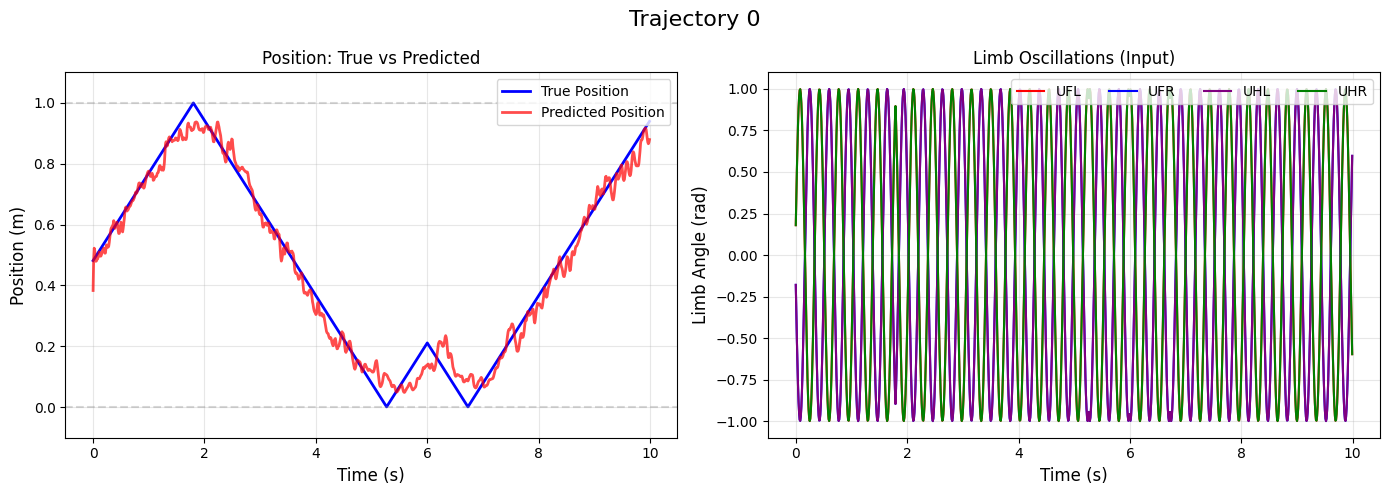

  Trajectory 0 - MSE: 0.174657, MAE: 0.340175


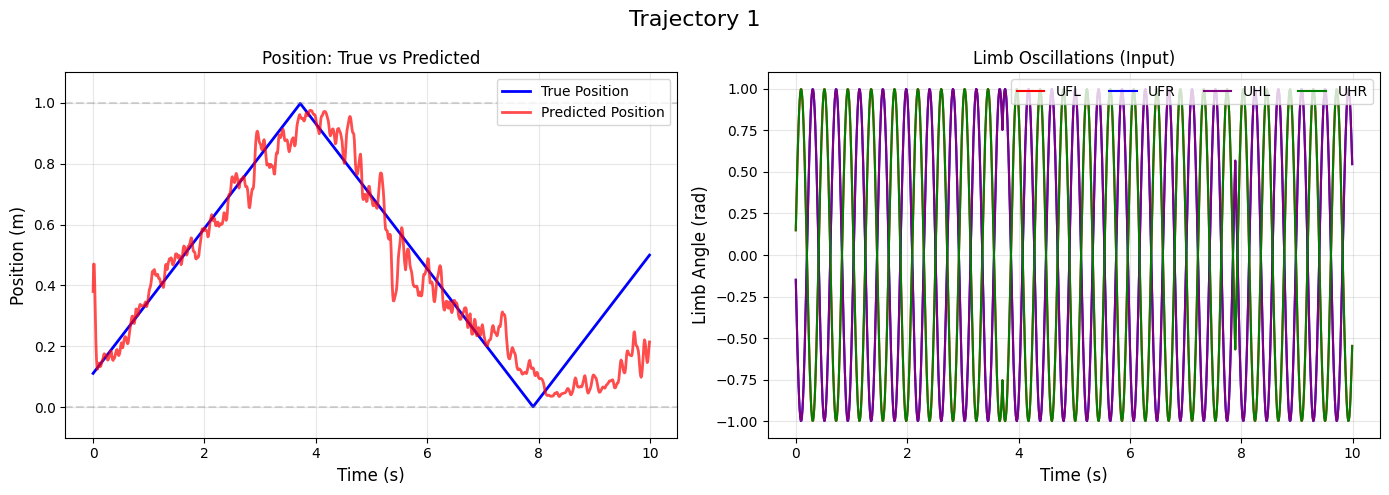

  Trajectory 1 - MSE: 0.163217, MAE: 0.328396


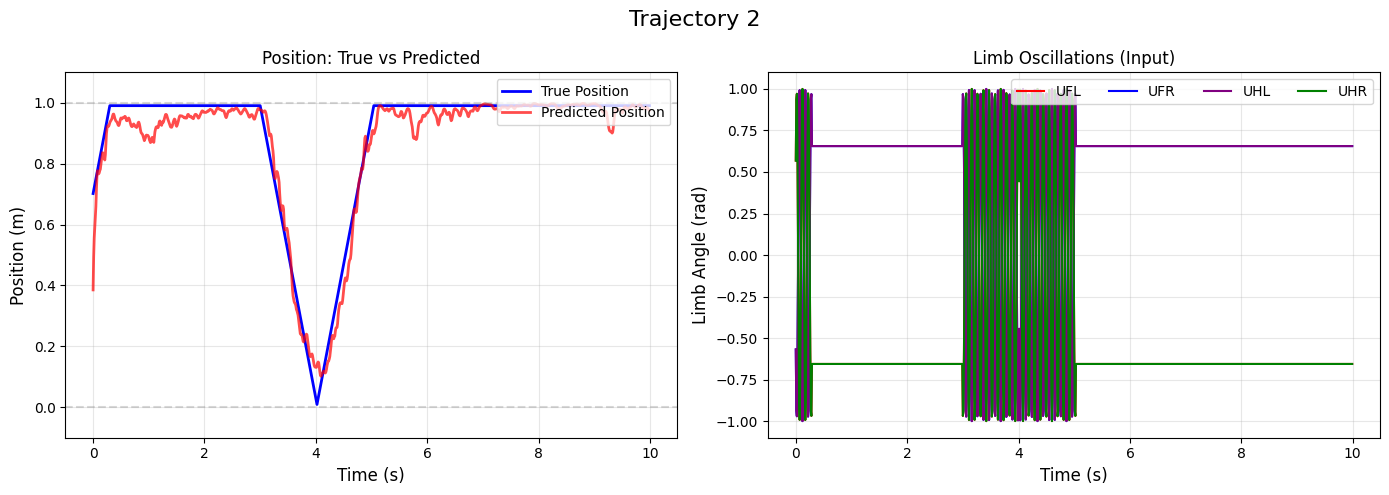

  Trajectory 2 - MSE: 0.109673, MAE: 0.191451


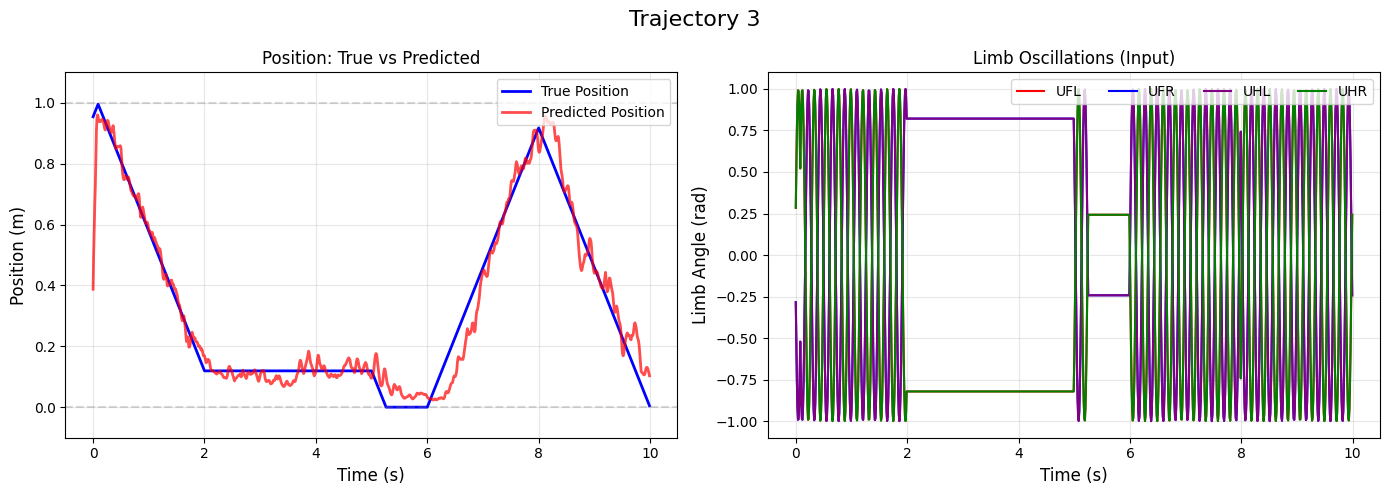

  Trajectory 3 - MSE: 0.168200, MAE: 0.317268


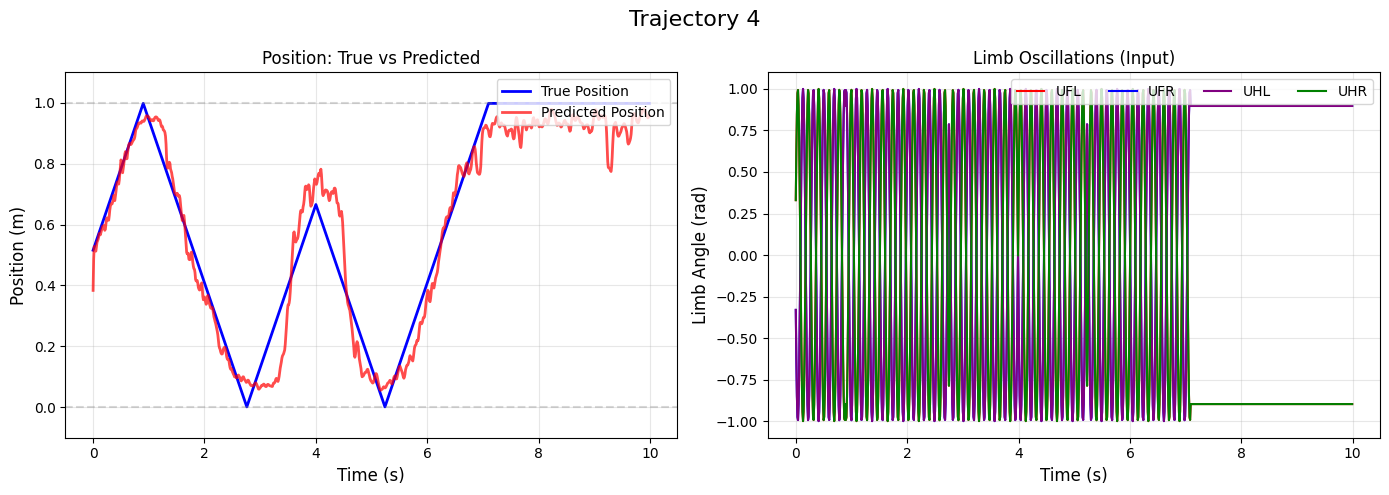

  Trajectory 4 - MSE: 0.218905, MAE: 0.377668


In [148]:
def plot_predictions(inputs, outputs, predictions, time_series, num_plots=5):
    """
    Plot predictions vs ground truth in 2-column layout:
    Left: Position (true vs predicted)
    Right: Limb Oscillations (input)
    """
    for i in range(num_plots):
        traj_index = i
        
        # Extract data
        true_position = outputs['position'][traj_index]
        pred_position = predictions[traj_index]
        limb_osc = inputs['limb_osc'][traj_index]
        UFL, UFR, UHL, UHR = limb_osc.T
        
        # Create figure with 1x2 grid
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Trajectory {traj_index}", fontsize=16)
        
        # ============ LEFT: Position ============
        ax1 = axes[0]
        ax1.plot(time_series, true_position, color='blue', linewidth=2, label='True Position')
        ax1.plot(time_series, pred_position, color='red', linewidth=2, 
                 alpha=0.7, label='Predicted Position')
        ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.3)
        ax1.set_xlabel('Time (s)', fontsize=12)
        ax1.set_ylabel('Position (m)', fontsize=12)
        ax1.set_title('Position: True vs Predicted')
        ax1.set_ylim(-0.1, 1.1)
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)
        
        # ============ RIGHT: Limb Oscillations ============
        ax2 = axes[1]
        ax2.plot(time_series, UFL, label='UFL', color='red', linewidth=1.5)
        ax2.plot(time_series, UFR, label='UFR', color='blue', linewidth=1.5)
        ax2.plot(time_series, UHL, label='UHL', color='purple', linewidth=1.5)
        ax2.plot(time_series, UHR, label='UHR', color='green', linewidth=1.5)
        ax2.set_xlabel('Time (s)', fontsize=12)
        ax2.set_ylabel('Limb Angle (rad)', fontsize=12)
        ax2.set_title('Limb Oscillations (Input)')
        ax2.legend(ncol=4, loc='upper right')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print error metrics for this trajectory
        mse = np.mean((true_position - pred_position) ** 2)
        mae = np.mean(np.abs(true_position - pred_position))
        print(f"  Trajectory {traj_index} - MSE: {mse:.6f}, MAE: {mae:.6f}")

# After getting predictions from model
plot_predictions(inputs, outputs, pos_pred, total_time_series, num_plots=5)


In [149]:
# Compute metrics for position predictions

# outputs dict contains numpy arrays from data generation
true_positions = torch.tensor(outputs['position'], dtype=torch.float32).to(device)
# predictions dict contains model output tensors
predicted_positions = predictions['position'].clone().detach().squeeze(-1)

# Mean Squared Error (MSE)
mse = torch.mean((true_positions - predicted_positions) ** 2)

# Root Mean Squared Error (RMSE)
rmse = torch.sqrt(mse)

# Mean Absolute Error (MAE)
mae = torch.mean(torch.abs(true_positions - predicted_positions))

print("Position Metrics:")
print(f"  Mean Squared Error (MSE): {mse.item():.6f}")
print(f"  Root Mean Squared Error (RMSE): {rmse.item():.6f}")
print(f"  Mean Absolute Error (MAE): {mae.item():.6f}")

Position Metrics:
  Mean Squared Error (MSE): 0.003892
  Root Mean Squared Error (RMSE): 0.062386
  Mean Absolute Error (MAE): 0.044076


In [150]:
# Generating test data

np.random.seed(42)
torch.manual_seed(42)

test_visual_cue, test_trajectory_data, test_limb_oscillations, test_phase_data, test_omega_data = generate_trajectory_limb_data(num_trajectories=10)

test_inputs, test_outputs = structure_data_to_dicts(test_visual_cue, test_trajectory_data, test_limb_oscillations, test_phase_data, test_omega_data)

X_test = np.concatenate([test_inputs['visual_cue'], test_inputs['limb_osc']], axis=-1)  # (N, T, 6)
Y_test = test_outputs['position'][:,:,np.newaxis]  # (N, T, 1)

In [151]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    test_predictions = model(X_test_tensor)
    test_pos_pred = test_predictions["position"].cpu().numpy()

print("Test prediction shape:", test_pos_pred.shape)   # (N_test, T, 2)

# Compute errors (flatten over time)
true_test_pos = torch.tensor(Y_test, dtype=torch.float32)
pred_test_pos = torch.tensor(test_pos_pred, dtype=torch.float32)

true_flat = true_test_pos.view(-1, 2)
pred_flat = pred_test_pos.view(-1, 2)

mse = torch.mean((true_flat - pred_flat) ** 2).item()
rmse = mse ** 0.5
mae = torch.mean(torch.abs(true_flat - pred_flat)).item()

print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")

Test prediction shape: (10, 1000, 1)
MSE: 0.003581
RMSE: 0.059838
MAE: 0.044927


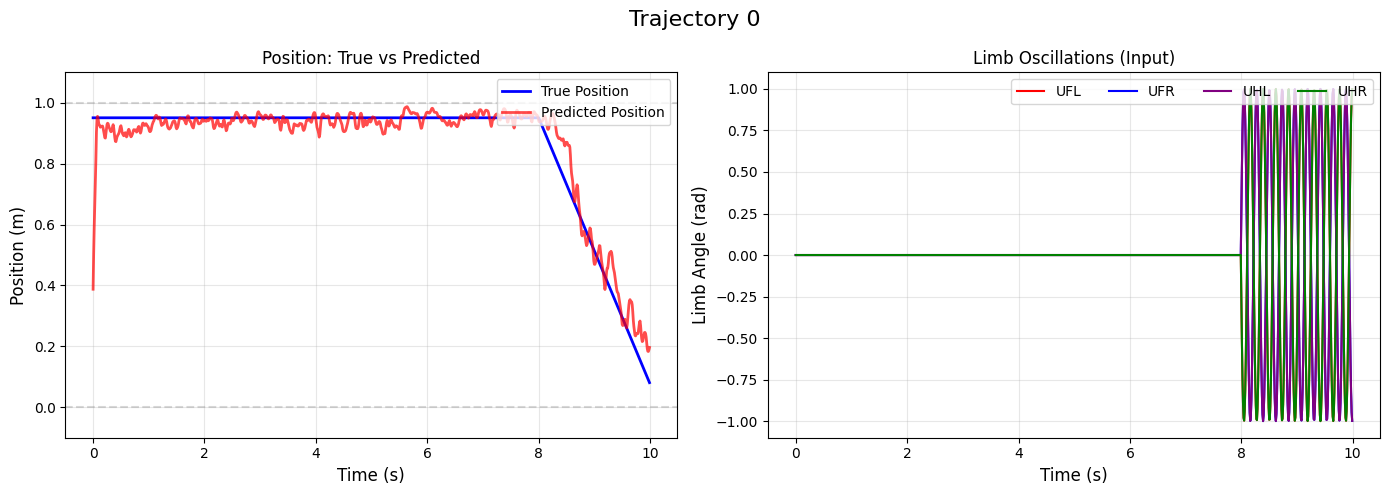

  Trajectory 0 - MSE: 0.078527, MAE: 0.153934


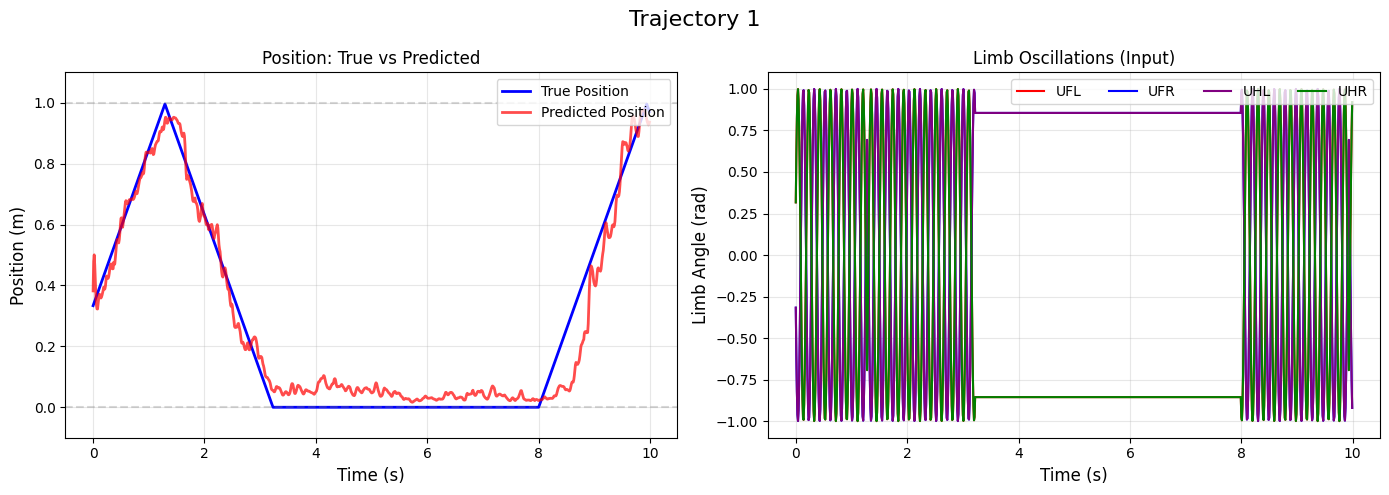

  Trajectory 1 - MSE: 0.216396, MAE: 0.354553


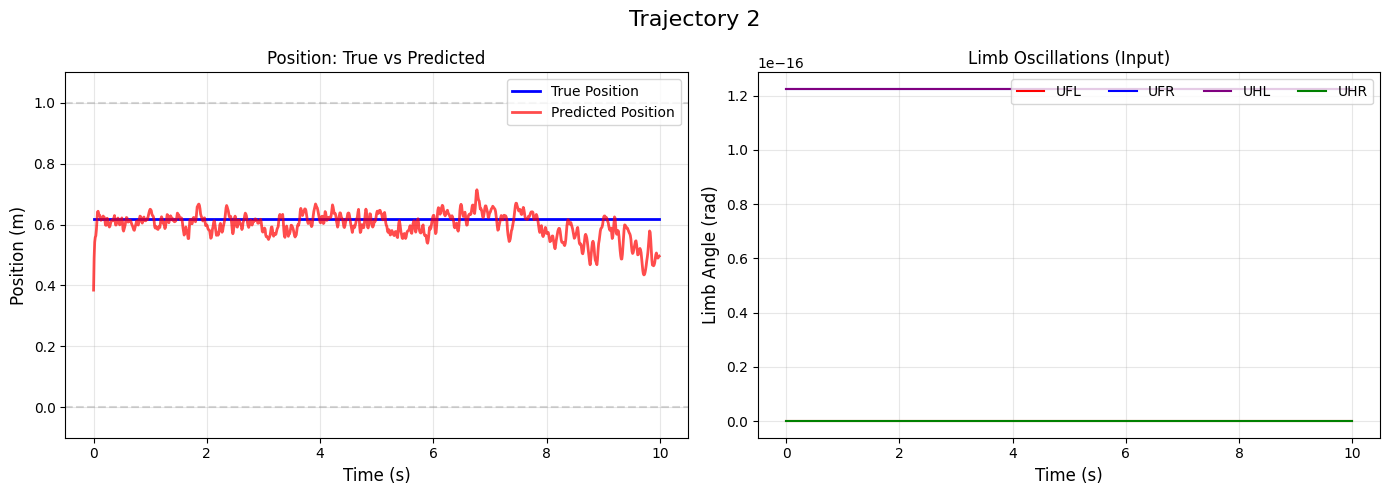

  Trajectory 2 - MSE: 0.002192, MAE: 0.033437


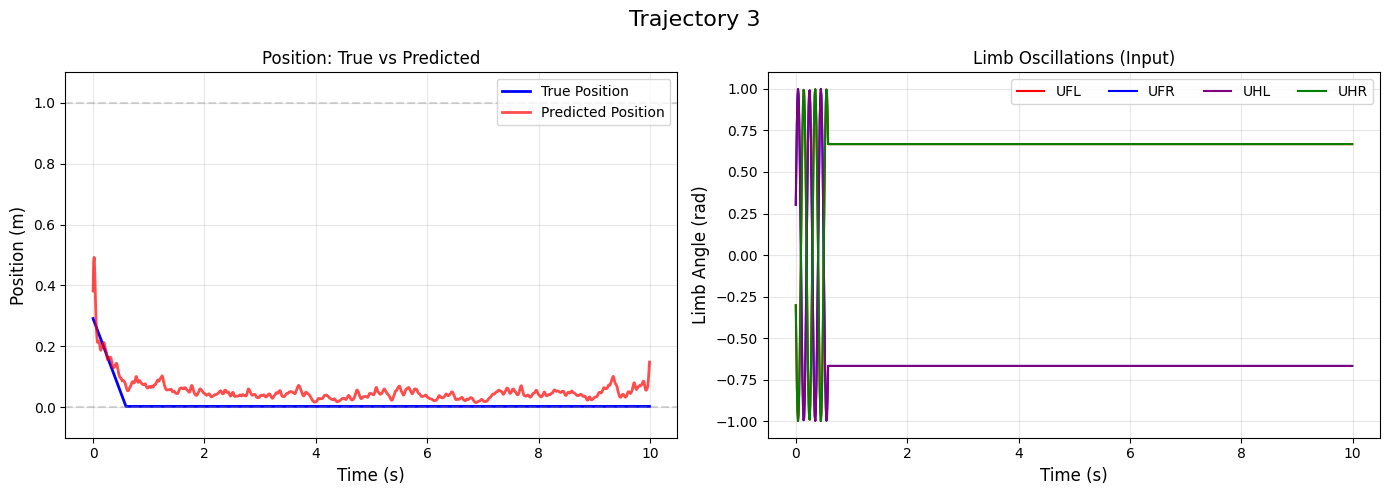

  Trajectory 3 - MSE: 0.005184, MAE: 0.054817


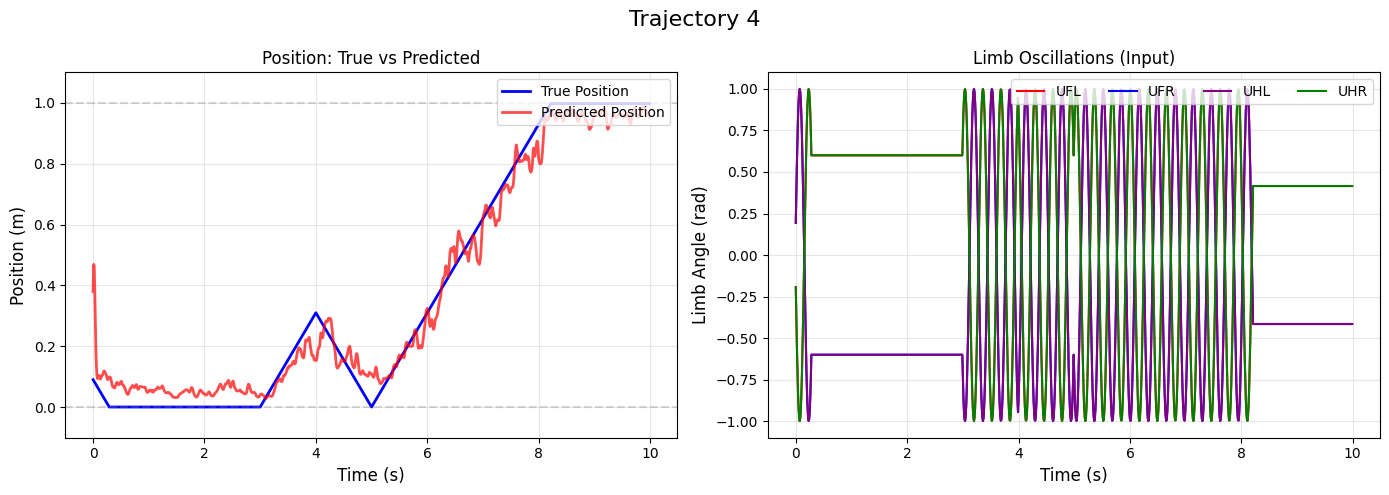

  Trajectory 4 - MSE: 0.280107, MAE: 0.409473


In [152]:
# Plotting test predictions
plot_predictions(test_inputs, test_outputs, test_pos_pred, total_time_series, num_plots=5)

In [154]:
# Saving files 

traj_folder = "/Users/ais/Desktop/2026_Summer/correct data/25thjun"
traj_file = f"traj_data.pkl"
trajectory_path = os.path.join(traj_folder, traj_file)

trajectory_data = Y_test[:, :, :]

with open(trajectory_path, "wb") as f:
        pickle.dump(trajectory_data, f)

activations_folder = "/Users/ais/Desktop/2026_Summer/correct data/25thjun"

# all layers
layer_names = ['d1', "z1", 'd2', "z2", 'd3', "z3"]
layers = [d1_out, z1_out, d2_out, z2_out, d3_out, z3_out]
for layer_name, layer in zip(layer_names, layers):
    activations_file = f"activations_{layer_name}.pkl"
    activations_path = os.path.join(activations_folder, activations_file)
    
    with open(activations_path, "wb") as f:
        pickle.dump(layer[:, :, :], f)
  

### Place Cell Suitable Data

In [155]:

def generate_controlled_trajectory(start_pos, end_pos, velocity_magnitude, pause_times=None, pause_duration=0):
    """
    Generate a trajectory with controlled start/end positions and optional pauses.
    Returns only the timesteps needed to complete the trajectory.
    
    Parameters:
    -----------
    start_pos : float - Starting position (0 or 1)
    end_pos : float - Ending position (0 or 1)
    velocity_magnitude : float - Speed of movement (m/s)
    pause_times : list - Positions (0-1) where pauses occur
    pause_duration : float - Duration of each pause (in seconds)
    
    Returns:
    --------
    trajectory_data : array (T, 2) - [position, velocity] at each timestep
    """
    
    direction = 1 if end_pos > start_pos else -1
    distance = abs(end_pos - start_pos)
    
    # Calculate travel time (without pauses)
    travel_time = distance / velocity_magnitude
    
    # Total pause time
    num_pauses = len(pause_times) if pause_times else 0
    total_pause_time = num_pauses * pause_duration
    
    # Total trajectory time
    total_time = travel_time + total_pause_time
    num_steps = int(total_time / dt)
    
    trajectory_data = []
    current_position = start_pos
    
    # Convert pause positions to actual positions along trajectory
    pause_positions = pause_times if pause_times else []
    pause_remaining = {pos: int(pause_duration / dt) for pos in pause_positions}
    
    for t in range(num_steps):
        # Check if we're at a pause position
        in_pause = False
        for pause_pos in pause_positions:
            if pause_remaining[pause_pos] > 0:
                # Check if current position is at or past pause position
                if direction == 1 and current_position >= pause_pos:
                    in_pause = True
                    pause_remaining[pause_pos] -= 1
                    break
                elif direction == -1 and current_position <= pause_pos:
                    in_pause = True
                    pause_remaining[pause_pos] -= 1
                    break
        
        if in_pause:
            velocity = 0.0
        else:
            # Check if we've reached the destination
            if (direction == 1 and current_position >= end_pos) or \
               (direction == -1 and current_position <= end_pos):
                break  # Stop trajectory when destination reached
            else:
                velocity = direction * velocity_magnitude
        
        trajectory_data.append([current_position, velocity])
        
        # Update position for next timestep
        next_position = current_position + velocity * dt
        next_position = np.clip(next_position, track_min, track_max)
        current_position = next_position
    
    return np.array(trajectory_data)


def generate_visual_cue_1d(position_series, track_min=0, track_max=1):
    """Generate visual cues as inverse distances to track boundaries."""
    position_series = np.array(position_series)
    T = len(position_series)
    
    visual_cues = np.zeros((T, 2), dtype=np.float32)
    
    dist_to_min = np.abs(position_series - track_min)
    visual_cues[:, 0] = 1.0 - dist_to_min
    
    dist_to_max = np.abs(position_series - track_max)
    visual_cues[:, 1] = 1.0 - dist_to_max
    
    return visual_cues


def generate_limb_oscillations(velocity_series):
    """Generate limb oscillations from velocity series."""
    
    omega_t = 2 * np.pi * (velocity_series / am)
    phase_t = np.cumsum(omega_t * dt)
    
    UFL = theta_m * np.sin(phase_t)
    UFR = theta_m * np.sin(phase_t + phi)
    UHL = theta_m * np.sin(phase_t + phi)
    UHR = theta_m * np.sin(phase_t)
    
    limb_oscillations = np.stack([UFL, UFR, UHL, UHR], axis=-1)
    
    return limb_oscillations, phase_t, omega_t


def create_place_cell_test_data():
    """
    Create test dataset for place cell analysis with variable-length trajectories.
    
    Returns list of trajectories (not padded arrays) for pure spatial consistency.
    """
    
    trajectories = []  # List of dicts, each containing one trajectory's data
    
    # =============== NO PAUSES ===============
    
    # 3 Forward trajectories (0 → 1) at different speeds
    forward_speeds = [0.15, 0.25, 0.4]
    for speed in forward_speeds:
        traj = generate_controlled_trajectory(start_pos=0.0, end_pos=1.0, velocity_magnitude=speed)
        visual_cue = generate_visual_cue_1d(traj[:, 0])
        limb_osc, phase, omega = generate_limb_oscillations(traj[:, 1])
        
        trajectories.append({
            'label': f"Forward_v{speed}_nopause",
            'position': traj[:, 0],
            'velocity': traj[:, 1],
            'visual_cue': visual_cue,
            'limb_osc': limb_osc,
            'phase': phase,
            'omega': omega,
            'X': np.concatenate([visual_cue, limb_osc], axis=-1),  # Model input (T, 6)
            'Y': traj[:, 0:1],  # Model output (T, 1)
            'duration': len(traj) * dt,
            'num_steps': len(traj)
        })
    
    # 3 Backward trajectories (1 → 0) at different speeds
    backward_speeds = [0.15, 0.25, 0.4]
    for speed in backward_speeds:
        traj = generate_controlled_trajectory(start_pos=1.0, end_pos=0.0, velocity_magnitude=speed)
        visual_cue = generate_visual_cue_1d(traj[:, 0])
        limb_osc, phase, omega = generate_limb_oscillations(traj[:, 1])
        
        trajectories.append({
            'label': f"Backward_v{speed}_nopause",
            'position': traj[:, 0],
            'velocity': traj[:, 1],
            'visual_cue': visual_cue,
            'limb_osc': limb_osc,
            'phase': phase,
            'omega': omega,
            'X': np.concatenate([visual_cue, limb_osc], axis=-1),
            'Y': traj[:, 0:1],
            'duration': len(traj) * dt,
            'num_steps': len(traj)
        })
    
    # =============== WITH PAUSES (at spatial positions) ===============
    
    # 2 Forward trajectories with pauses at different spatial positions
    forward_pause_configs = [
        {'speed': 0.2, 'pause_positions': [0.3], 'pause_duration': 2.0},  # pause at pos 0.3
        {'speed': 0.2, 'pause_positions': [0.5], 'pause_duration': 2.0},  # pause at pos 0.5
    ]
    
    for cfg in forward_pause_configs:
        traj = generate_controlled_trajectory(
            start_pos=0.0, end_pos=1.0,
            velocity_magnitude=cfg['speed'],
            pause_times=cfg['pause_positions'],
            pause_duration=cfg['pause_duration']
        )
        visual_cue = generate_visual_cue_1d(traj[:, 0])
        limb_osc, phase, omega = generate_limb_oscillations(traj[:, 1])
        
        trajectories.append({
            'label': f"Forward_v{cfg['speed']}_pause@{cfg['pause_positions'][0]}",
            'position': traj[:, 0],
            'velocity': traj[:, 1],
            'visual_cue': visual_cue,
            'limb_osc': limb_osc,
            'phase': phase,
            'omega': omega,
            'X': np.concatenate([visual_cue, limb_osc], axis=-1),
            'Y': traj[:, 0:1],
            'duration': len(traj) * dt,
            'num_steps': len(traj)
        })
    
    # 2 Backward trajectories with pauses
    backward_pause_configs = [
        {'speed': 0.2, 'pause_positions': [0.7], 'pause_duration': 2.0},  # pause at pos 0.7
        {'speed': 0.2, 'pause_positions': [0.5], 'pause_duration': 2.0},  # pause at pos 0.5
    ]
    
    for cfg in backward_pause_configs:
        traj = generate_controlled_trajectory(
            start_pos=1.0, end_pos=0.0,
            velocity_magnitude=cfg['speed'],
            pause_times=cfg['pause_positions'],
            pause_duration=cfg['pause_duration']
        )
        visual_cue = generate_visual_cue_1d(traj[:, 0])
        limb_osc, phase, omega = generate_limb_oscillations(traj[:, 1])
        
        trajectories.append({
            'label': f"Backward_v{cfg['speed']}_pause@{cfg['pause_positions'][0]}",
            'position': traj[:, 0],
            'velocity': traj[:, 1],
            'visual_cue': visual_cue,
            'limb_osc': limb_osc,
            'phase': phase,
            'omega': omega,
            'X': np.concatenate([visual_cue, limb_osc], axis=-1),
            'Y': traj[:, 0:1],
            'duration': len(traj) * dt,
            'num_steps': len(traj)
        })
    
    return trajectories


# =====================================================================
# GENERATE TEST DATA
# =====================================================================

place_cell_trajectories = create_place_cell_test_data()

print("=" * 60)
print("PLACE CELL TEST DATA - VARIABLE LENGTH TRAJECTORIES")
print("=" * 60)
for i, traj in enumerate(place_cell_trajectories):
    print(f"{i}: {traj['label']:35s} | Steps: {traj['num_steps']:5d} | Duration: {traj['duration']:.2f}s")
print("=" * 60)


PLACE CELL TEST DATA - VARIABLE LENGTH TRAJECTORIES
0: Forward_v0.15_nopause               | Steps:   666 | Duration: 6.66s
1: Forward_v0.25_nopause               | Steps:   400 | Duration: 4.00s
2: Forward_v0.4_nopause                | Steps:   250 | Duration: 2.50s
3: Backward_v0.15_nopause              | Steps:   666 | Duration: 6.66s
4: Backward_v0.25_nopause              | Steps:   400 | Duration: 4.00s
5: Backward_v0.4_nopause               | Steps:   250 | Duration: 2.50s
6: Forward_v0.2_pause@0.3              | Steps:   700 | Duration: 7.00s
7: Forward_v0.2_pause@0.5              | Steps:   700 | Duration: 7.00s
8: Backward_v0.2_pause@0.7             | Steps:   700 | Duration: 7.00s
9: Backward_v0.2_pause@0.5             | Steps:   700 | Duration: 7.00s


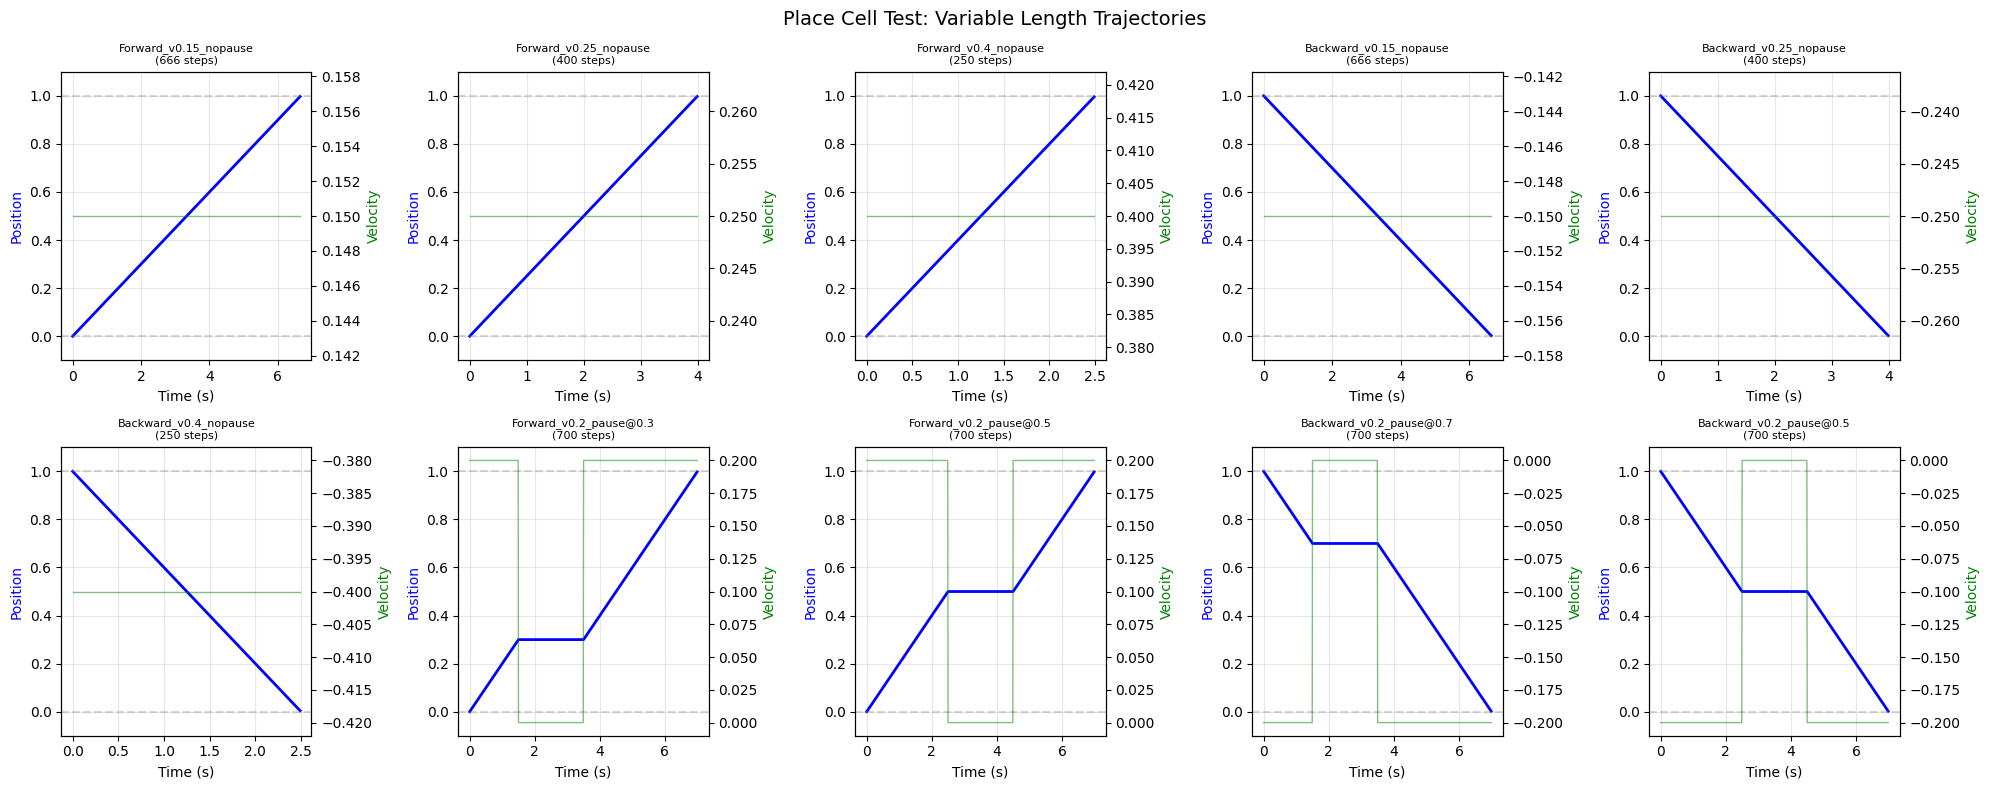

In [156]:
# =====================================================================
# VISUALIZE TEST TRAJECTORIES
# =====================================================================

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Place Cell Test: Variable Length Trajectories', fontsize=14)

for i, (ax, traj) in enumerate(zip(axes.flatten(), place_cell_trajectories)):
    t = np.arange(traj['num_steps']) * dt
    
    ax2 = ax.twinx()
    ax.plot(t, traj['position'], 'b-', linewidth=2, label='Position')
    ax2.plot(t, traj['velocity'], 'g-', linewidth=1, alpha=0.5, label='Velocity')
    
    ax.set_ylim(-0.1, 1.1)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.3)
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position', color='blue')
    ax2.set_ylabel('Velocity', color='green')
    ax.set_title(f"{traj['label']}\n({traj['num_steps']} steps)", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [157]:
def oscillator_loop_dynamic(X_r, X_i, omegas, dt=0.01, input_scaler=5):
    """
    Dynamic version that uses actual input length instead of fixed num_steps.
    """
    batch_size, num_steps, units = X_r.shape  # Get length from input
    
    r_t = torch.ones((batch_size, units), device=X_r.device)
    phis = torch.zeros((batch_size, units), device=X_r.device)

    r_list, phi_list = [], []

    for t in range(num_steps):  # Use actual input length
        input_r = input_scaler * X_r[:, t, :] * torch.cos(phis)
        input_phi = input_scaler * X_i[:, t, :] * torch.sin(phis)

        r_t = r_t + ((1 - r_t**2) * r_t + input_r) * dt
        phis = phis + (omegas - input_phi) * dt

        r_list.append(r_t.unsqueeze(1))
        phi_list.append(phis.unsqueeze(1))

    r_arr = torch.cat(r_list, dim=1)
    phi_arr = torch.cat(phi_list, dim=1)
    return r_arr, phi_arr


def hopf_forward_dynamic(hopf_module, z_complex):
    """Forward pass using dynamic length."""
    X_r = z_complex.real
    X_i = z_complex.imag
    
    r, phi = oscillator_loop_dynamic(X_r, X_i, hopf_module.omegas)
    
    z_real = r * torch.cos(phi)
    z_imag = r * torch.sin(phi)
    return torch.complex(z_real, z_imag)


def model_inference_dynamic(model, X):
    """
    Run inference with variable-length input.
    Bypasses fixed num_steps in Hopf oscillators.
    """
    X_c = torch.complex(X, torch.zeros_like(X))
    
    # Layer 1
    d1 = model.d1(X_c)
    z1 = hopf_forward_dynamic(model.osc1, d1)
    
    # Layer 2
    d2 = model.d2(z1)
    z2 = hopf_forward_dynamic(model.osc2, d2)
    
    # Layer 3
    d3 = model.d3(z2)
    z3 = hopf_forward_dynamic(model.osc3, d3)
    
    # Output layers
    z3_concat = torch.cat([z3.real, z3.imag], dim=-1)
    z3_abs = torch.abs(z3)
    d4 = model.d4(z3_abs)
    pos_out = model.pos_out(d4)
    
    return {
        "position": pos_out,
        "d1": d1,
        "z1": z1,
        "d2": d2,
        "z2": z2,
        "d3": d3,
        "z3": z3,
        "d4": d4
    }



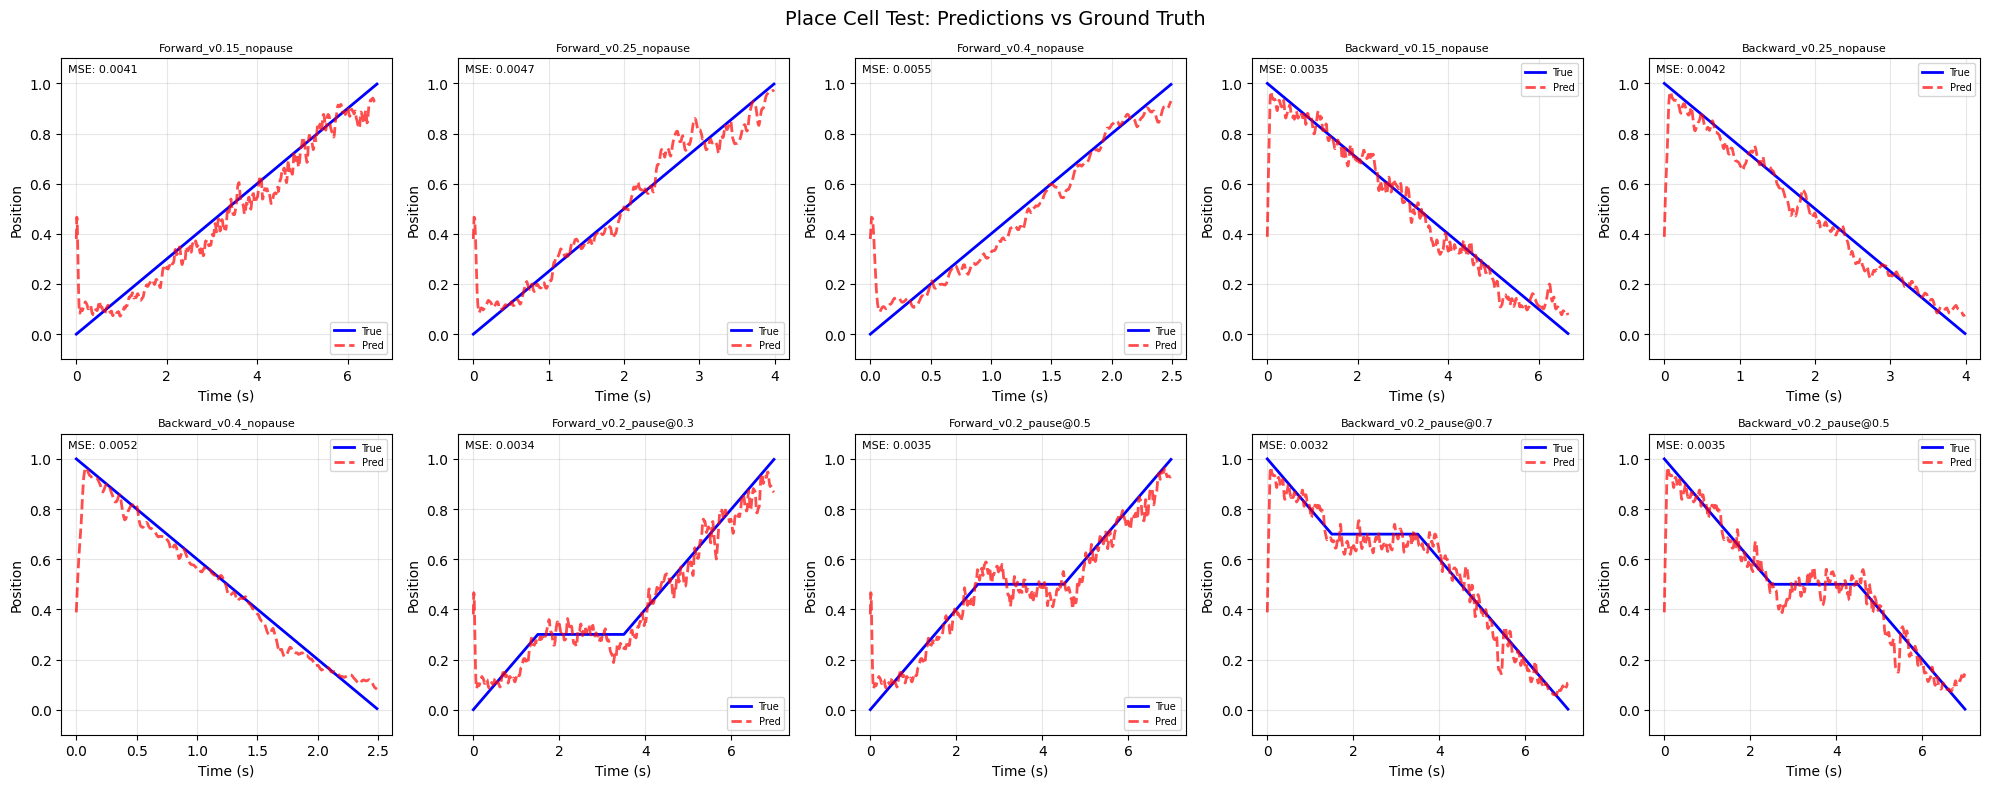

In [106]:
model.eval()

for traj in place_cell_trajectories:
    with torch.no_grad():
        X_tensor = torch.tensor(traj['X'], dtype=torch.float32).unsqueeze(0).to(device)  # (1, T, 6)
        predictions = model(X_tensor)
        traj['pred_position'] = predictions['position'].squeeze().cpu().numpy() # (T,)

# Plot predictions vs ground truth
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Place Cell Test: Predictions vs Ground Truth', fontsize=14)

for i, (ax, traj) in enumerate(zip(axes.flatten(), place_cell_trajectories)):
    t = np.arange(traj['num_steps']) * dt
    
    ax.plot(t, traj['position'], 'b-', linewidth=2, label='True')
    ax.plot(t, traj['pred_position'], 'r--', linewidth=2, alpha=0.7, label='Pred')
    
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position')
    ax.set_title(traj['label'], fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    
    mse = np.mean((traj['position'] - traj['pred_position']) ** 2)
    ax.text(0.02, 0.98, f'MSE: {mse:.4f}', transform=ax.transAxes, fontsize=8, va='top')

plt.tight_layout()
plt.show()


In [159]:
model.eval()

# Store everything here
trajectory_results = []

for i, traj in enumerate(place_cell_trajectories):

    print(f"Running trajectory {i+1}/{len(place_cell_trajectories)} "
          f"({traj['label']})")

    X_tensor = torch.tensor(
        traj["X"],
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)      # (1, T, 6)

    with torch.no_grad():
        outputs = model_inference_dynamic(model, X_tensor)

    result = {
        "label": traj["label"],
        "position": traj["position"],
        "pred_position": outputs["position"].squeeze().cpu().numpy(),

        "d1": outputs["d1"].squeeze(0).cpu().numpy(),
        "z1": outputs["z1"].squeeze(0).cpu().numpy(),

        "d2": outputs["d2"].squeeze(0).cpu().numpy(),
        "z2": outputs["z2"].squeeze(0).cpu().numpy(),

        "d3": outputs["d3"].squeeze(0).cpu().numpy(),
        "z3": outputs["z3"].squeeze(0).cpu().numpy(),
    }

    trajectory_results.append(result)

Running trajectory 1/10 (Forward_v0.15_nopause)
Running trajectory 2/10 (Forward_v0.25_nopause)
Running trajectory 3/10 (Forward_v0.4_nopause)
Running trajectory 4/10 (Backward_v0.15_nopause)
Running trajectory 5/10 (Backward_v0.25_nopause)
Running trajectory 6/10 (Backward_v0.4_nopause)
Running trajectory 7/10 (Forward_v0.2_pause@0.3)
Running trajectory 8/10 (Forward_v0.2_pause@0.5)
Running trajectory 9/10 (Backward_v0.2_pause@0.7)
Running trajectory 10/10 (Backward_v0.2_pause@0.5)


In [181]:
print(trajectory_results[0].keys())

dict_keys(['label', 'position', 'pred_position', 'd1', 'z1', 'd2', 'z2', 'd3', 'z3'])


In [173]:
for i, traj in enumerate(place_cell_trajectories):
    print(f"Trajectory {i+1}: {traj['Y'].shape}")

Trajectory 1: (666, 1)
Trajectory 2: (400, 1)
Trajectory 3: (250, 1)
Trajectory 4: (666, 1)
Trajectory 5: (400, 1)
Trajectory 6: (250, 1)
Trajectory 7: (700, 1)
Trajectory 8: (700, 1)
Trajectory 9: (700, 1)
Trajectory 10: (700, 1)


In [182]:
# save traj file
import os
import pickle

save_folder = "/Users/ais/Desktop/2026_Summer/correct data/25thjun"
os.makedirs(save_folder, exist_ok=True)

save_path = os.path.join(save_folder, "trajectory_results.pkl")

with open(save_path, "wb") as f:
    pickle.dump(trajectory_results, f)

print(f"Saved trajectory results to:\n{save_path}")

Saved trajectory results to:
/Users/ais/Desktop/2026_Summer/correct data/25thjun/trajectory_results.pkl
